# DEEP LEARNING ASSIGNMENT

In [19]:
"""
Tool usage acknowledgement:

ChatGPT (OpenAI) was used as an assistive tool for debugging,
code clarification, plotting guidance, and formatting support.
All model architectures, training logic, and experimental design
decisions were implemented and validated by the author.
"""

'\nTool usage acknowledgement:\n\nChatGPT (OpenAI) was used as an assistive tool for debugging,\ncode clarification, plotting guidance, and formatting support.\nAll model architectures, training logic, and experimental design\ndecisions were implemented and validated by the author.\n'

## Loading Dataset

In [ ]:
"""
Reference:
1. Lab(Advanced): ResNet-18 (data loading, eda)

2. Abhishek (Medium). "Fine-tuning a Pre-trained ResNet-18 Model for Image Classification on Custom Dataset with PyTorch."
https://medium.com/@imabhi1216/fine-tuning-a-pre-trained-resnet-18-model-for-image-classification-on-custom-dataset-with-pytorch-02df12e83c2c 
(for data augmentation, data loaders)
"""

In [2]:
import os #import os for file operations
from pathlib import Path # import pathlib for extracting dataset 
import pandas as pd # pandas for 
import numpy as np # numpy for numerical operations
import matplotlib.pyplot as plt # visualization and plotting of images and data
from PIL import Image 
import ast

plt.style.use("default")
plt.rcParams["figure.figsize"] = (6,4)

DATA_ROOT = Path("/Users/sivagangareghu/Desktop/Lab3 /DL Assignment/2025_Dataset") # extracting path of datatset directories
# adding all the directories "P#_R#" which represents each class of pitch and roll pose into list pose_folders
pose_folders = [
    f for f in DATA_ROOT.iterdir()
    if f.is_dir() 
    and f.name.startswith("P") 
    and "_R" in f.name
]
print("Number of pose folders:", len(pose_folders)) # printing length of "pose_folders", which is the number of classes/ poses in the dataset

Number of pose folders: 40


## Parsing Labels

In [3]:
records = [] # list to store each class data 

for pose_dir in pose_folders: # iterating through all the directories in the dataset
    pose_name = pose_dir.name   # each folder name represents the pitch and roll, for example "P10_R0", its name is stores in variable pose_name
    # Extract pitch and roll values
    pitch = int(pose_name.split("_")[0].replace("P","")) # storing the pitch value, if pose_name = P10_R0, pitch = 10
    roll  = int(pose_name.split("_")[1].replace("R","")) # storing the roll value, if pose_name = P10_R0, roll = 0

    # Each image in the datset also contains an associated depth value stored in {pose_name}-depth.txt file
    depth_file = pose_dir / f"{pose_name}_depth.txt" # extrating the depth txt file for the corresponding pitch and roll folder
    depth_map = {} # initializing an array to store the depth values 

    with open(depth_file, "r") as f: # opening each depth file 
        for line in f:
            fname, d = ast.literal_eval(line.strip()) # extarcting the depth values and name associated with the file
            depth_map[fname] = float(d) # storing the corresponding depth values of each image in the directory under the corresponding name 

    # Linking each image to the depth (image_name = f_name in depth_map)
    for img_path in sorted(pose_dir.glob("*.jpg")): # sorting the directory
        fname = img_path.name # setting the fname to the name of the image to be sure
        if fname in depth_map: # storing corresponding image information under the depth value in depth_map
            records.append({
                "image_path": img_path,
                "pose_folder": pose_name,
                "pitch_deg": pitch,
                "roll_deg": roll,
                "depth": depth_map[fname]
            })

df = pd.DataFrame(records)# converts list of dictionaries(each data point) into structured data in tabular form
df.head() # printing first few rows for verification

,image_path,pose_folder,pitch_deg,roll_deg,depth
0,/Users/sivagangareghu/Desktop/Lab3 /DL Assignm...,P45_R5,45,5,0.240
1,/Users/sivagangareghu/Desktop/Lab3 /DL Assignm...,P45_R5,45,5,0.238
2,/Users/sivagangareghu/Desktop/Lab3 /DL Assignm...,P45_R5,45,5,0.239
3,/Users/sivagangareghu/Desktop/Lab3 /DL Assignm...,P45_R5,45,5,0.430
4,/Users/sivagangareghu/Desktop/Lab3 /DL Assignm...,P45_R5,45,5,0.597


## Exploratory Data Analysis

In [4]:
# CHECKING FOR ANY CORRUPT IMAGES#
bad_indices = []
bad_paths = []

for idx, row in df.iterrows(): # iterating through the structured tabular data created
    img_path = row["image_path"] # storing each image in a variable
    try:
        with Image.open(img_path) as img:
            img.verify()  # quick check that file is not corrupted by trying to open it
    except Exception as e:
        print(f"Corrupted image detected: {img_path} | error: {e}")
        bad_indices.append(idx) # adding index to list created
        bad_paths.append(img_path) #adding the corresponding path of the image to list created

print(f"\nTotal corrupted images found: {len(bad_indices)}") # printing total number of corrupt images


Total corrupted images found: 0


### Plotting random data for exploration

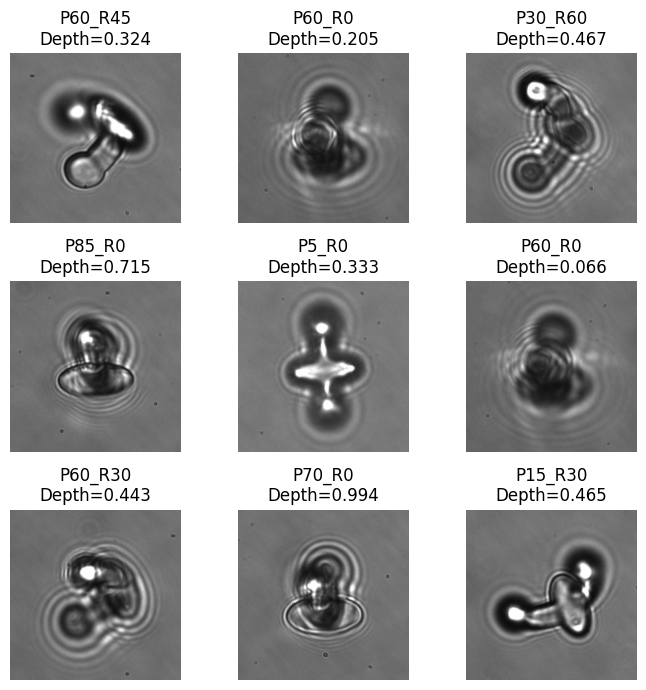

In [5]:

num_samples = 9
sample_rows = df.sample(num_samples, random_state=0) # sampling rows randomly in df

fig, axes = plt.subplots(3, 3, figsize=(7,7)) # adjusting plotting size
axes = axes.ravel()

for ax, (_, row) in zip(axes, sample_rows.iterrows()): # plotting image and correspoinding label
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{row['pose_folder']}\nDepth={row['depth']:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Checking for class imbalance

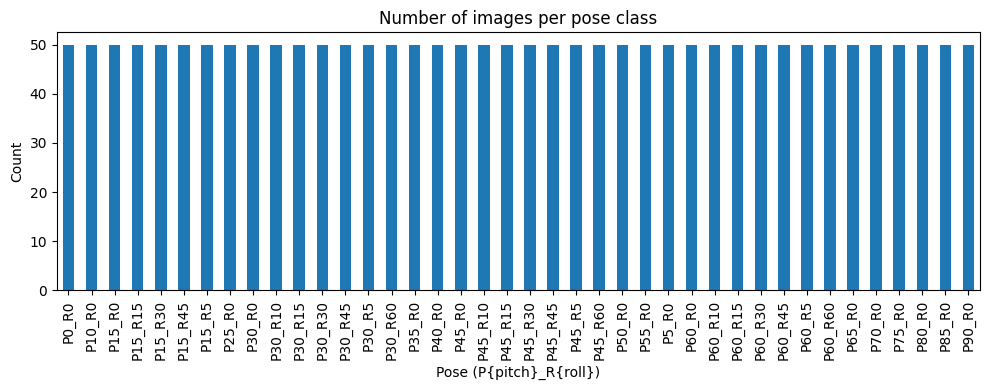

Summary of pose counts:
count    40.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0
Name: count, dtype: float64


In [6]:
# Count images in each pose class
pose_counts = df["pose_folder"].value_counts().sort_index()

# plotting bar gaph of class distribution
plt.figure(figsize=(10,4))
pose_counts.plot(kind="bar")
plt.title("Number of images per pose class")
plt.xlabel("Pose (P{pitch}_R{roll})")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Summary of pose counts:")
print(pose_counts.describe()) # checking mean, median, and standard deviation of class distribution

### Checking pitch and roll distributions

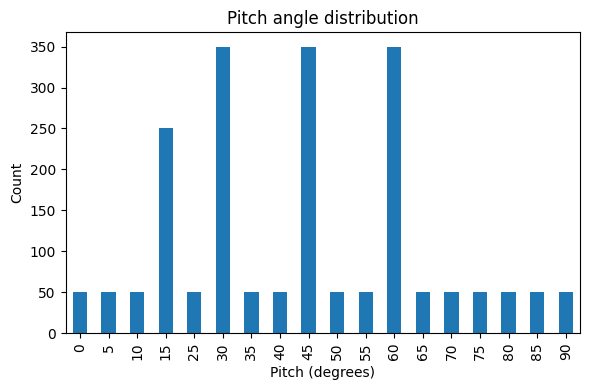

Pitch counts:
 pitch_deg
0      50
5      50
10     50
15    250
25     50
30    350
35     50
40     50
45    350
50     50
55     50
60    350
65     50
70     50
75     50
80     50
85     50
90     50
Name: count, dtype: int64


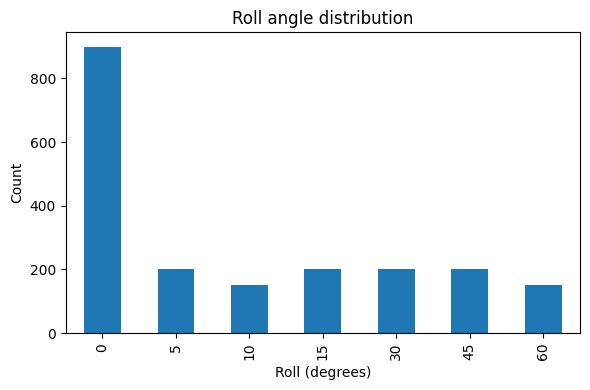

Roll counts:
 roll_deg
0     900
5     200
10    150
15    200
30    200
45    200
60    150
Name: count, dtype: int64


In [7]:
# Pitch distribution count
pitch_counts = df["pitch_deg"].value_counts().sort_index()

#plotting distribution as a bar graph
plt.figure()
pitch_counts.plot(kind="bar")
plt.title("Pitch angle distribution")
plt.xlabel("Pitch (degrees)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Pitch counts:\n", pitch_counts)

# Roll distribution count
roll_counts = df["roll_deg"].value_counts().sort_index()

# plotting roll distribution as a bar graph
plt.figure()
roll_counts.plot(kind="bar")
plt.title("Roll angle distribution")
plt.xlabel("Roll (degrees)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Roll counts:\n", roll_counts)

### Checking distribution of depth

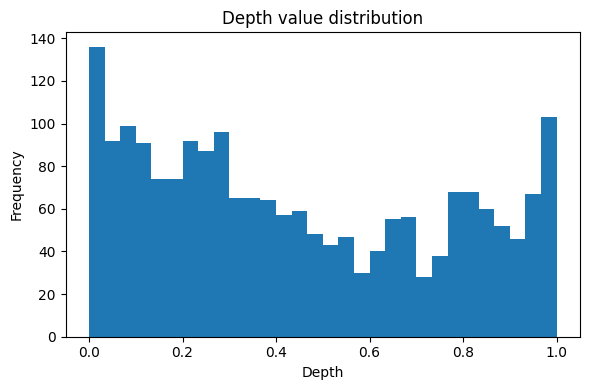

count    2000.000000
mean        0.443198
std         0.312163
min         0.000000
25%         0.171750
50%         0.382000
75%         0.735250
max         1.000000
Name: depth, dtype: float64


In [8]:
#plotting the distribution of all the depth values
plt.figure()
plt.hist(df["depth"], bins=30)
plt.title("Depth value distribution")
plt.xlabel("Depth")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df["depth"].describe())

### Checking for outliers in depth values

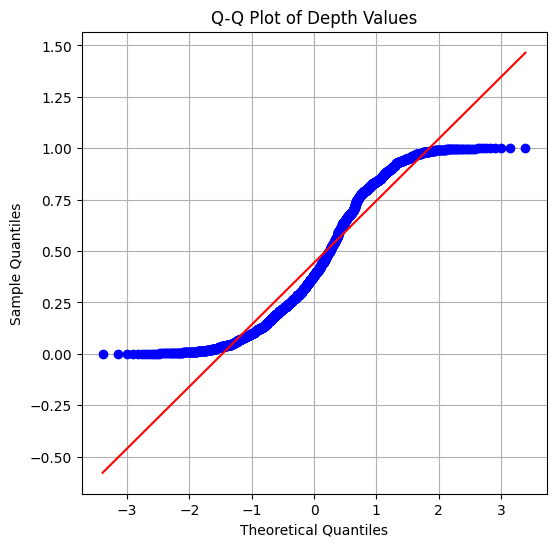

In [9]:

import scipy.stats as stats # importing scipy for plotting Q-Q plots
import matplotlib.pyplot as plt

# Storing Depth values 
depth_values = df["depth"].values

# Generate Q-Q plot of depth values to check for outliers
plt.figure(figsize=(6,6))
stats.probplot(depth_values, dist="norm", plot=plt)

plt.title("Q-Q Plot of Depth Values")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()

## Pixel Normalization and Depth Standardization & Data Splitting 60:20:20

In [10]:
# creating numeric id for all pose classes
pose_classes = sorted(df["pose_folder"].unique()) #sorting all the classes and storing in pose_classes
#linking each pose with a unique id for classification
pose_to_id = {pose: idx for idx, pose in enumerate(pose_classes)}
id_to_pose = {idx: pose for pose, idx in pose_to_id.items()}

df["pose_class_id"] = df["pose_folder"].map(pose_to_id) # adding pose id to df wher eeach class has a unique id

print("Number of pose classes:", len(pose_classes))
df[["pose_folder", "pose_class_id"]].head() # printing first few rows including only pose_folder and pose_id for verification

Number of pose classes: 40


,pose_folder,pose_class_id
0,P45_R5,22
1,P45_R5,22
2,P45_R5,22
3,P45_R5,22
4,P45_R5,22


### Depth Normalization and Train-Validation-Test Split

In [11]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split( # 60% train and 40% in temp_df
    df,
    test_size=0.4,  # 40% goes to val+test
    random_state=42, # setting random state to ensure results are reproducible for comparison
    stratify=df["pose_class_id"], # ensure the classses are propotionate between the train-valid-test splits
)

val_df, test_df = train_test_split( #20% val_df and 20% test_df
    temp_df,
    test_size=0.5,  # of the remaining 40% -> 20% val, 20% test
    random_state=42,
    stratify=temp_df["pose_class_id"],
)

print("Split sizes:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

# Standardise depth using training data
depth_mean_train = train_df["depth"].mean() # mean of depth in tarining data
depth_std_train  = train_df["depth"].std() # dtandard deviation of depth in training data

print("\nTrain depth mean:", depth_mean_train)
print("Train depth std :", depth_std_train)

# function to add normalized depth 
def add_depth_norm(sub_df):
    sub_df = sub_df.copy()
    sub_df["depth_norm"] = (sub_df["depth"] - depth_mean_train) / depth_std_train
    return sub_df

# adding normalization of depth to train test and valid sets
train_df = add_depth_norm(train_df)
val_df   = add_depth_norm(val_df)
test_df  = add_depth_norm(test_df)

print("\nNormalised depth (train) summary:")
print(train_df["depth_norm"].describe())

Split sizes:
Train: 1200
Val:   400
Test:  400

Train depth mean: 0.4465958333333333
Train depth std : 0.3137411705281534

Normalised depth (train) summary:
count    1.200000e+03
mean     1.125026e-16
std      1.000000e+00
min     -1.423453e+00
25%     -8.632779e-01
50%     -2.058889e-01
75%      9.606778e-01
max      1.763888e+00
Name: depth_norm, dtype: float64


### Data Augmentation and Pixel Normalization

In [12]:
from torchvision import transforms
# Data Augmentation for training set and normalization

IMG_SIZE = 224  # setting image size for resizing to be compatible with CNN models

train_transforms = T.Compose([ 
    T.Resize((IMG_SIZE, IMG_SIZE)), # resiszing image accoring to CNNs
    T.ColorJitter(brightness=0.1, contrast=0.1), # brightness and contrast augmentations
    #small translations and scaling without rotation to ensure that eh poses remain unchanged
    T.RandomAffine(
        degrees=0,              
        translate=(0.02, 0.02), # up to 2% shift in x,y
        scale=(0.95, 1.05),     # slight scaling in and out
    ),
    
    T.ToTensor(),
    # Normalization of pixel values, by converting gray scale to RGB for consistency
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# not augmenting the val and test data and just normalizing the pixel values 
val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

### Dataset Class for Initialization

In [13]:
# Intializing structured dataset as a class for pose classification adn depth estimation
# It retunrs the image as tensor, pose_id, and normlaized depth
class MicrorobotDataset(Dataset):
    # initialization function
    def __init__(self, df, transforms=None, use_normalised_depth=True):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.use_normalised_depth = use_normalised_depth

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # extracting image as garyscale
        img_path = row["image_path"]
        # converting to RGB
        image = Image.open(img_path).convert("RGB")
        
        if self.transforms is not None:
            image = self.transforms(image)
        # setting label as pose_id previously initialized
        pose_label = int(row["pose_class_id"])
        
        if self.use_normalised_depth and "depth_norm" in row:
            depth = float(row["depth_norm"]) # returns normalized depth if set to true
        else:
            depth = float(row["depth"])
        
        return image, pose_label, depth

### Data Loader 

In [14]:
# structuring tarining, valid, and test data using Microrobot class fucntions
train_dataset = MicrorobotDataset(train_df, transforms=train_transforms, use_normalised_depth=True)
val_dataset   = MicrorobotDataset(val_df,   transforms=val_test_transforms, use_normalised_depth=True)
test_dataset  = MicrorobotDataset(test_df,  transforms=val_test_transforms, use_normalised_depth=True)
# printing legth for verification
print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))
print("Test samples: ", len(test_dataset))
# initializing batch size as 32 for tarining
BATCH_SIZE = 32
# Loading training data
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
# Loading validation data
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
# Loading test data
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Train samples: 1200
Val samples:   400
Test samples:  400


### Run all kernels before this for data loading and augmentation

# ------------------------------------------ Paste Code for Testing Here ---------------------------------------

## Pose Estimation

1.ResNet-18

2.ResNet-50

3.EfficientNet-B0

4.Fusion Model (Res+Eff)

### Helper Functions for Model Training and Evaluation

In [ ]:
"""
References / inspiration for this training + evaluation pipeline:

1) PyTorch Tutorials — “Training a Classifier” (official example of training loops, loss, and evaluation)
   https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

2) PyTorch Vision — Model Zoo / pretrained models (ResNet/EfficientNet usage patterns)
   https://pytorch.org/vision/stable/models.html

3) scikit-learn Metrics — accuracy, precision/recall/F1, confusion matrix, classification report, ROC-AUC, PR-AUC
   https://scikit-learn.org/stable/modules/model_evaluation.html
"""

In [ ]:
# Helper functions for computing accuracy, precision, recall, F1 score, confusion matrix, and plotting training and validation loss curve#
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (           # importing essential metrics using sklearn library for evaluation metrics
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

# function to compute accuracy 
# Parameters: logits: unnormalized values from model Targets: pose_id of true classes
# output:average accurcay and loss
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1) #prediction per sample
    correct = (preds == targets).sum().item() # if correct add +1
    total = targets.size(0)# total size of targets (test set)
    return correct / total # returns accuracy [0,1]

# function for training model for each epoch and storing trai loss and accuracy
# Parameters: model, data_loader,optimizer,loss_function,and device(GPU)
def train_one_epoch_pose(
    model: nn.Module, # classifier 
    dataloader: torch.utils.data.DataLoader,# data loader 
    optimizer: optim.Optimizer,# optimizer 
    criterion: nn.Module, #loss function
    device: torch.device, #GPU
):
    model.train() #train model
    running_loss = 0.0 #initialize 
    running_acc = 0.0
    total_batches = 0
    #iterate through each image and corresponding pose_label in data
    for images, pose_labels in dataloader: 
        # move images and labelsto device
        images = images.to(device) 
        pose_labels = pose_labels.to(device)
        
        optimizer.zero_grad() #clear old gradients
        
        logits = model(images) #forward pass 
        loss = criterion(logits, pose_labels) #compute loss
        
        loss.backward() #backward pass to compute new weights
        optimizer.step()#update new weights 
        
        acc = accuracy_from_logits(logits.detach(), pose_labels) # compute accuracy of the updated model 
        
        running_loss += loss.item() # loss and accuracy
        running_acc  += acc #add accuracy computed
        total_batches += 1 #increment batch
    
    return running_loss / total_batches, running_acc / total_batches # return average train accurcay and loss


# function: evaluate accuracy and loss on test set or validation set without training
# parameters: model, dataloader(valid or test),loss function,device
# output:average accurcay and loss
@torch.no_grad() # no gradients are stored for faster computation
def evaluate_pose(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval() # evaluation mode
    # initialize variables for incrementing loss,accurcay and batch
    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0
    #iterate through images and labels in validation or test set data from corresponding dataloaders
    for images, pose_labels in dataloader:
        #trandfer images and labels for testing or validation to device
        images = images.to(device)
        pose_labels = pose_labels.to(device)
        
        logits = model(images) #forward pass through model to get prediction
        loss = criterion(logits, pose_labels)#compute the loss
        
        acc = accuracy_from_logits(logits, pose_labels)#compute accuracy using raw values and true values
        
        running_loss += loss.item() #sum loss for each sample
        running_acc  += acc#sum accuracy
        total_batches += 1#increment batch
    
    return running_loss / total_batches, running_acc / total_batches #return average accuracy and loss 
#function: full training loop over 15 epochs to track training curve and restore best model by validation
#parameters:model, training data loader, validation data loader, device, epochs =15,learning rate =1e-3 (default values)
#output:training and validation loss and accuracy history over the epochs for plotting curves and validation accuracy of chosen model weights
def train_pose_model(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    num_epochs: int = 15,
    lr: float = 1e-3,
):
    criterion = nn.CrossEntropyLoss() # loss function : cross entropy
    optimizer = optim.Adam(model.parameters(), lr=lr) #optimiztion function initialized as Adam with learning rate and weights of model
    
    #dictionaries for storing training loss and accurcay over each epoch
    train_history = {"loss": [], "acc": []}
    val_history   = {"loss": [], "acc": []}
    # initializing vairables to store best validation accurcay and bets state
    best_val_acc = 0.0
    best_state_dict = None

    #for each epoch
    for epoch in range(1, num_epochs + 1):
        #train one epoch and store train loss and accuracy in variables
        train_loss, train_acc = train_one_epoch_pose( 
            model, train_loader, optimizer, criterion, device
        )
        # evaluate validation loss and accuracy over one epoch with updated weights 
        val_loss, val_acc = evaluate_pose(
            model, val_loader, criterion, device
        )
        # store values of train and validation loss, accuracy for plotting curve
        train_history["loss"].append(train_loss)
        train_history["acc"].append(train_acc)
        val_history["loss"].append(val_loss)
        val_history["acc"].append(val_acc)
        # if validation accuracy has increase
        if val_acc > best_val_acc:
            best_val_acc = val_acc # store the best accurcay in best_val_acc 
            best_state_dict = model.state_dict() #store model parameters in best_state_dict
        # printing current validation and training loss and accuracy scores for monitroing
        print(
            f"Epoch {epoch:02d}/{num_epochs} "
            f"| Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
            f"| Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )
    
    # Load best model (validation)
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        print(f"\nLoaded best model with val acc = {best_val_acc:.4f}")
    
    return train_history, val_history, best_val_acc # returns the dictionaries containing training and validation loss and accuracy, and final bets model validation accuracy

#function: plot training and validation curves
#parameters: training and validation history as dictionaries, model name
def plot_training_curves(
    train_history: dict,
    val_history: dict,
    title_prefix: str = "Model",
):
    epochs = range(1, len(train_history["loss"]) + 1) # no. of epochs for x-axis
    
    plt.figure(figsize=(10,4))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(epochs, train_history["loss"], label="Train") # epochs vs. train loss
    plt.plot(epochs, val_history["loss"], label="Val") # epochs vs. validation loss
    #Axis labels
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    # Model name as title - Loss
    plt.title(f"{title_prefix} - Loss")
    plt.legend() # Legend for train and valid

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(epochs, train_history["acc"], label="Train")# epochs vs. train accuracy
    plt.plot(epochs, val_history["acc"], label="Val") # epochs vs. validation accuracy
    #Axis labels
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    # Model name as title - Accuracy
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()# Legend for train and valid

    plt.tight_layout() # ensures figures fit
    plt.show()

# funtion: run inference over dataloader to get true labels, predicted labels, and probabilities for confusion matrix
#parameters: model, dataloader, device
#output:predicted classes, true classes, probabilities of predicted classes
@torch.no_grad()
def get_preds_labels_probs(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
):
    model.eval() # set model for evaluation mode
    all_logits = [] #list for storing raw predictions
    all_labels = []#list for storing true labels
    
    #for each image and corresponding pose in dataloader
    for images, pose_labels in dataloader:
        #transfer images and labels to device
        images = images.to(device)
        pose_labels = pose_labels.to(device)
        
        logits = model(images) # raw predicted values
        
        all_logits.append(logits.cpu()) # append predicted value in all_logits list
        all_labels.append(pose_labels.cpu()) #append true value in all_labels list
    
    #concatenate logits and labels
    all_logits = torch.cat(all_logits, dim=0) 
    all_labels = torch.cat(all_labels, dim=0).numpy()
    # converts logits to probabilities using softmax(dim=1)
    all_probs = torch.softmax(all_logits, dim=1).numpy()
    all_preds = all_probs.argmax(axis=1) #maximum probability class gives the predicted class
    
    return all_preds, all_labels, all_probs

# funtion: evaluation metrics computing and plotting
# parameters: model, test set, device, total number of classes, model name
# output: a dictionary containing evaluation metrics values of model on test set (accuracy, precision, recall, F1 score, confusion matrix, PR ROC AUC)
def evaluate_pose_model(
    model: nn.Module,
    test_loader: torch.utils.data.DataLoader,
    device: torch.device,
    num_classes: int,
    model_name: str = "Model",
):
    # get predicted and true values from previous function using model and their corresponding probabilities
    y_pred, y_true, y_proba = get_preds_labels_probs(
        model, test_loader, device
    )
    
    # compute precision, recall, accuracy and F1 score using sklearn metrics functions, with true and predicted labels list
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0 # macro ensures average metric equally across classes
    )
    # Print metrics
    print(f"[{model_name}] Test Accuracy: {acc:.4f}")
    print(f"[{model_name}] Macro Precision: {prec:.4f}")
    print(f"[{model_name}] Macro Recall:    {rec:.4f}")
    print(f"[{model_name}] Macro F1-score:  {f1:.4f}\n")
    # prints classification report using sklearn library function
    print(f"[{model_name}] Classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # plotting Confusion matrix
    cm = confusion_matrix(y_true, y_pred) # store confusion matrix in cm using sklearn function
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.tight_layout()
    plt.show()
    
    # printing ROC AUC  and PR AUC
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    
    try:
        roc_auc_macro = roc_auc_score(
            y_true, y_proba, multi_class="ovr", average="macro"
        )
    except ValueError:
        roc_auc_macro = np.nan  # in case of edge cases
    
    try:
        pr_auc_macro = average_precision_score(
            y_true_bin, y_proba, average="macro"
        )
    except ValueError:
        pr_auc_macro = np.nan
    
    print(f"[{model_name}] Macro ROC AUC: {roc_auc_macro:.4f}")
    print(f"[{model_name}] Macro PR AUC:  {pr_auc_macro:.4f}")

    # store and return all the metrics
    metrics = {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "roc_auc_macro": roc_auc_macro,
        "pr_auc_macro": pr_auc_macro,
        "confusion_matrix": cm,
    }
    return metrics


In [ ]:
"""
Reference:
1. Abhishek (Medium). "Fine-tuning a Pre-trained ResNet-18 Model for Image Classification on Custom Dataset with PyTorch."
https://medium.com/@imabhi1216/fine-tuning-a-pre-trained-resnet-18-model-for-image-classification-on-custom-dataset-with-pytorch-02df12e83c2c 
(for ResNet Implementation for classification)
"""

### 1. ResNet 18 Implementation 

Epoch 01/15 | Train loss: 2.8849, acc: 0.1974 | Val loss: 1.8130, acc: 0.3438
Epoch 02/15 | Train loss: 1.2801, acc: 0.5428 | Val loss: 1.0504, acc: 0.6154
Epoch 03/15 | Train loss: 0.8489, acc: 0.6965 | Val loss: 0.5276, acc: 0.7716
Epoch 04/15 | Train loss: 0.5580, acc: 0.7993 | Val loss: 0.2907, acc: 0.8918
Epoch 05/15 | Train loss: 0.3341, acc: 0.8939 | Val loss: 0.2009, acc: 0.9279
Epoch 06/15 | Train loss: 0.2188, acc: 0.9359 | Val loss: 0.1393, acc: 0.9423
Epoch 07/15 | Train loss: 0.1797, acc: 0.9433 | Val loss: 0.1484, acc: 0.9471
Epoch 08/15 | Train loss: 0.1898, acc: 0.9400 | Val loss: 0.1311, acc: 0.9615
Epoch 09/15 | Train loss: 0.1885, acc: 0.9515 | Val loss: 0.1741, acc: 0.9423
Epoch 10/15 | Train loss: 0.1061, acc: 0.9712 | Val loss: 0.0236, acc: 0.9952
Epoch 11/15 | Train loss: 0.0629, acc: 0.9836 | Val loss: 0.0456, acc: 0.9880
Epoch 12/15 | Train loss: 0.1215, acc: 0.9613 | Val loss: 0.0680, acc: 0.9808
Epoch 13/15 | Train loss: 0.1102, acc: 0.9704 | Val loss: 0.0678

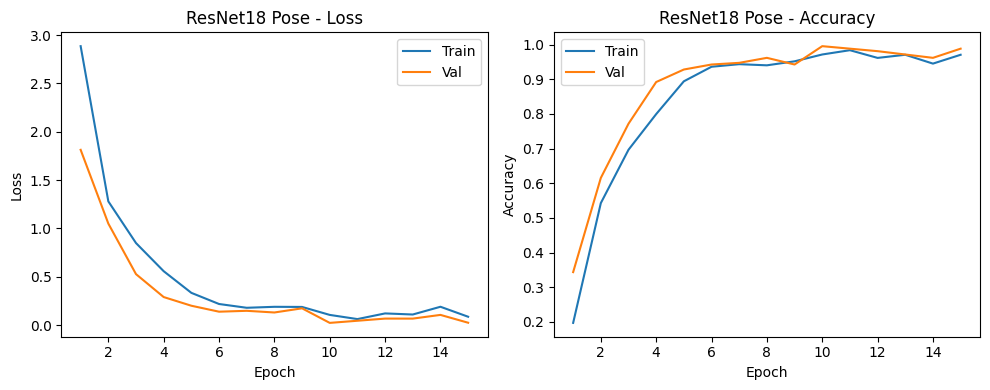

[ResNet18 Pose] Test Accuracy: 0.9825
[ResNet18 Pose] Macro Precision: 0.9875
[ResNet18 Pose] Macro Recall:    0.9825
[ResNet18 Pose] Macro F1-score:  0.9816

[ResNet18 Pose] Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       0.83      1.00      0.91        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       1.00      0.80      0.89  

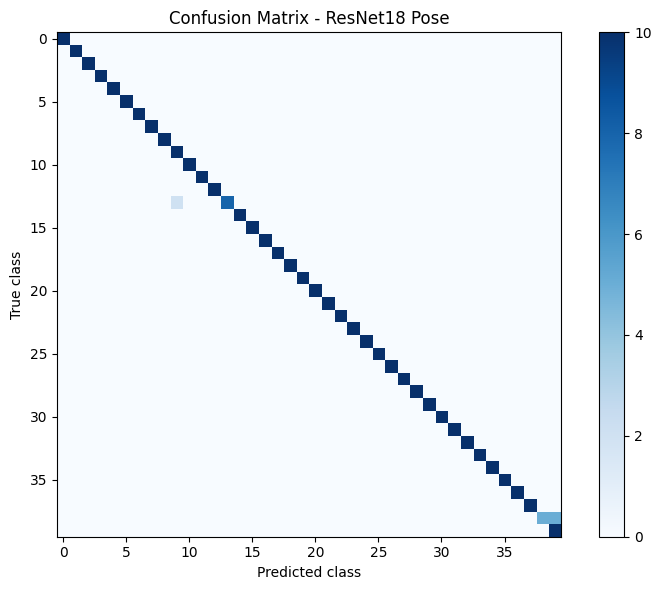

[ResNet18 Pose] Macro ROC AUC: 0.9999
[ResNet18 Pose] Macro PR AUC:  0.9985


In [ ]:
import torchvision.models as models
import torch.nn as nn

# setting device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = len(pose_classes)
# defining and modifying ResNet-18 model for pose classification#
class PoseClassifierResNet18(nn.Module):
    #initialization function
    #inputs: self, number of classes (40)
    def __init__(self, num_classes):
        super().__init__()
        # loading ResNet18 pretrained weights
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )
        num_features = self.backbone.fc.in_features  #extracting number of features(final layer output) in the pretrained ResNet model
        # modifying final output layer for compatability with pose classification
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5), # setting drop out rate as mentioned in the report
            nn.Linear(num_features, 256), #adding a linear layer to combine the final layer to 256 outputs, common default number used to ensure all the features can be learned
            nn.ReLU(inplace=True), # setting ReLU as activation function
            nn.Dropout(0.3), # setting dropout rate
            nn.Linear(256, num_classes) # output layer with 40 classes
        )
    # function to return the modifyed backbone
    def forward(self, x):
        return self.backbone(x)

#loading modifyed model
model_resnet18 = PoseClassifierResNet18(num_classes=num_classes).to(device)

#training with previously defined helper function, and extracting training and validation history
train_hist_r18, val_hist_r18, best_val_r18 = train_pose_model(
    model_resnet18,
    train_loader,
    val_loader,
    device,
    num_epochs=15,
    lr=1e-3
)

# plotting training and validation curves
plot_training_curves(train_hist_r18, val_hist_r18, title_prefix="ResNet18 Pose")

#evaluating trained model on test set 
metrics_r18 = evaluate_pose_model(
    model_resnet18,
    test_loader,
    device,
    num_classes=num_classes,
    model_name="ResNet18 Pose"
)

### 2. ResNet50 Implementation

In [ ]:
"""
References / inspiration for the ResNet50 image classification implementation:

Habib Eternal (Medium).
“Binary Image Classification Using ResNet50”.
https://medium.com/@habibeternal/binary-image-classification-using-resnet50-743166d67647

Additional references:
- PyTorch Vision Models (ResNet50):
  https://pytorch.org/vision/stable/models.html
- PyTorch Training & Evaluation Tutorials:
  https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
"""

Epoch 01/15 | Train loss: 3.0139, acc: 0.1505 | Val loss: 3.6510, acc: 0.1346
Epoch 02/15 | Train loss: 1.2979, acc: 0.5123 | Val loss: 1.9866, acc: 0.4111
Epoch 03/15 | Train loss: 0.8946, acc: 0.6645 | Val loss: 0.6079, acc: 0.7644
Epoch 04/15 | Train loss: 0.5920, acc: 0.7648 | Val loss: 0.8062, acc: 0.7091
Epoch 05/15 | Train loss: 0.4986, acc: 0.8265 | Val loss: 0.5818, acc: 0.8365
Epoch 06/15 | Train loss: 0.3497, acc: 0.8684 | Val loss: 0.5500, acc: 0.8510
Epoch 07/15 | Train loss: 0.3361, acc: 0.8890 | Val loss: 0.3469, acc: 0.8774
Epoch 08/15 | Train loss: 0.1947, acc: 0.9309 | Val loss: 0.0684, acc: 0.9880
Epoch 09/15 | Train loss: 0.1006, acc: 0.9671 | Val loss: 0.4183, acc: 0.8966
Epoch 10/15 | Train loss: 0.1965, acc: 0.9350 | Val loss: 0.2088, acc: 0.9279
Epoch 11/15 | Train loss: 0.2213, acc: 0.9375 | Val loss: 0.4096, acc: 0.9111
Epoch 12/15 | Train loss: 0.1956, acc: 0.9350 | Val loss: 0.1057, acc: 0.9736
Epoch 13/15 | Train loss: 0.1267, acc: 0.9605 | Val loss: 0.0554

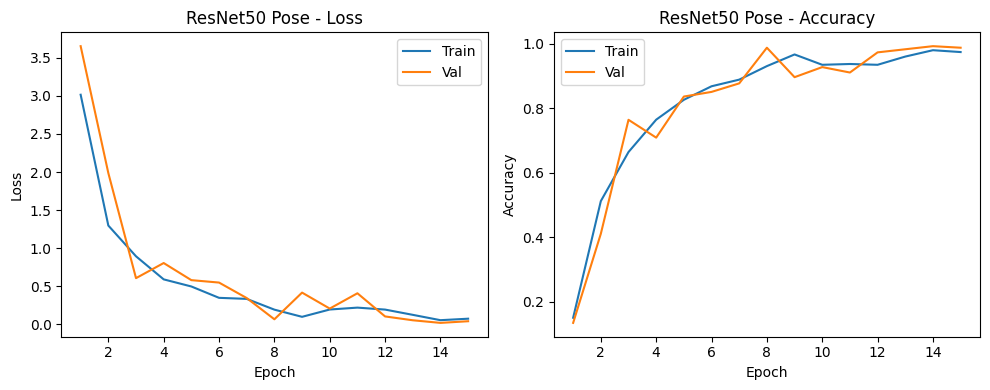

[ResNet50 Pose] Test Accuracy: 0.9650
[ResNet50 Pose] Macro Precision: 0.9718
[ResNet50 Pose] Macro Recall:    0.9650
[ResNet50 Pose] Macro F1-score:  0.9640

[ResNet50 Pose] Classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       1.00      0.90      0.95        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      0.90      0.95        10
          13       0.91      1.00      0.95  

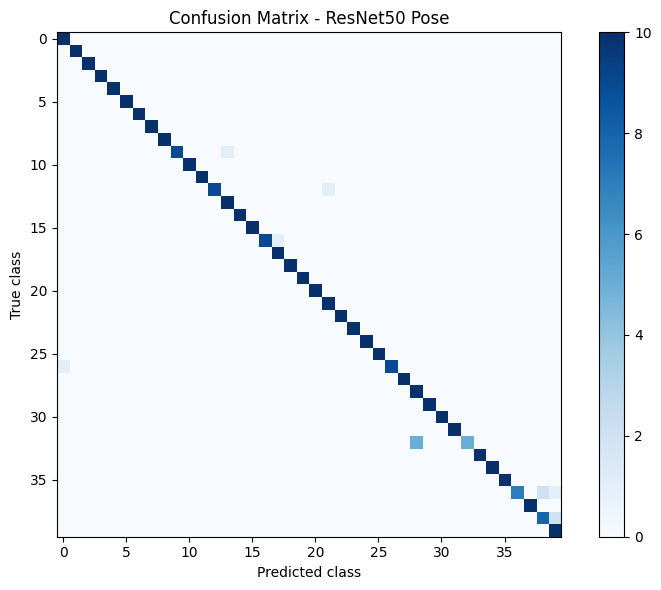

[ResNet50 Pose] Macro ROC AUC: 0.9997
[ResNet50 Pose] Macro PR AUC:  0.9939


In [ ]:
import torchvision.models as models  # import torchvision models for ResNet, Efficient Net weights
import torch.nn as nn  # import PyTorch neural network layers

#defining ResNet50 pose classification model
class PoseClassifierResNet50(nn.Module):  # modyfying the model
    def __init__(self, num_classes):  # constructor/ initialization fucntion that takes the number of classes (40)
        super().__init__()  # initialzinginthe parent 

        self.backbone = models.resnet50(# load the ResNet-50 backbone / architecture with weights 
            weights=models.ResNet50_Weights.DEFAULT # using defaul;t pretrainee ImegNet weights 
        )
        num_features = self.backbone.fc.in_features  # get the feature size in the model
        self.backbone.fc = nn.Sequential( # replace final layer with custom classification yaer for pose classification
            nn.Dropout(0.5), # applying drpout as stated in the report
            nn.Linear(num_features, 512), # makking linear layer to 512 to ensure all the features are considered 
            nn.ReLU(inplace=True), # ReLU activation
            nn.Dropout(0.3),# apply dropout with probability 0.3 for additional regularization
            nn.Linear(512, num_classes) # final linear layer mapping from 512 to 40
        )
    
    def forward(self, x):  # define forward pass
        return self.backbone(x)   # pass to return modified model backbone

model_resnet50 = PoseClassifierResNet50(num_classes=num_classes).to(device)# create model instance and move it to device 

# training the model
train_hist_r50, val_hist_r50, best_val_r50 = train_pose_model(# train the model and collect history using predefined helper function
    model_resnet50,  # model to be trained
    train_loader,# training data loader
    val_loader,# validation dataloader to calculate validation loss at each epoch
    device,# device 
    num_epochs=15,# number of training epochs
    lr=1e-3 # learning rate for the optimizer inside train_pose_model, as detailed in the report
)

#plotting curves for training and valdation loss using predefinedfucntion
plot_training_curves(train_hist_r50, val_hist_r50, title_prefix="ResNet50 Pose") 

# evaluation using predefined helper fucntion to plot metrics and confusion matrix
metrics_r50 = evaluate_pose_model(  # evaluate the trained model on the test dataset and compute metrics
    model_resnet50,# trained model to evaluate
    test_loader, # DataLoader providing test batches
    device,  # device 
    num_classes=num_classes, # number of classes (used for reports/confusion matrix calculations)
    model_name="ResNet50 Pose" # name for titles while printing metrics
)

### 3. EffiecntNet-B0 Implementation

In [ ]:
"""
References / inspiration for the EfficientNet-B0 image classification implementation:

Keras Documentation.
“Image classification via fine-tuning with EfficientNet”.
https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/

Additional references:
- Torchvision EfficientNet models:
  https://pytorch.org/vision/stable/models.html
- PyTorch Training & Evaluation Tutorials:
  https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
"""

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=40, bias=True)
)
Epoch 01/15 | Train loss: 2.3074, acc: 0.3692 | Val loss: 0.9876, acc: 0.6370
Epoch 02/15 | Train loss: 0.7445, acc: 0.7360 | Val loss: 0.5057, acc: 0.7885
Epoch 03/15 | Train loss: 0.4058, acc: 0.8528 | Val loss: 0.4503, acc: 0.8293
Epoch 04/15 | Train loss: 0.3487, acc: 0.8824 | Val loss: 0.1591, acc: 0.9615
Epoch 05/15 | Train loss: 0.1735, acc: 0.9449 | Val loss: 0.1177, acc: 0.9615
Epoch 06/15 | Train loss: 0.1116, acc: 0.9638 | Val loss: 0.0477, acc: 0.9832
Epoch 07/15 | Train loss: 0.1055, acc: 0.9704 | Val loss: 0.1334, acc: 0.9567
Epoch 08/15 | Train loss: 0.0961, acc: 0.9696 | Val loss: 0.2204, acc: 0.9784
Epoch 09/15 | Train loss: 0.1436, acc: 0.9605 | Val loss: 0.0794, acc: 0.9760
Epoch 10/15 | Train loss: 0.1121, acc: 0.9696 | Val loss: 0.1709, acc: 0.9712
Epoch 11/15 | Train loss: 0.1120, acc: 0.9655 | Val loss: 0.3560, acc: 0.9471
Epoch 12/15 | Train loss: 0.0793

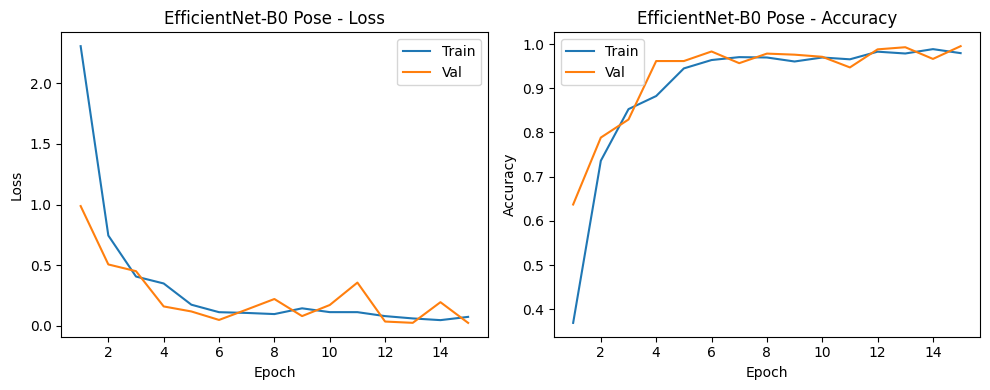

[EfficientNet-B0 Pose] Test Accuracy: 0.9850
[EfficientNet-B0 Pose] Macro Precision: 0.9871
[EfficientNet-B0 Pose] Macro Recall:    0.9850
[EfficientNet-B0 Pose] Macro F1-score:  0.9849

[EfficientNet-B0 Pose] Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       0.91      1.00      0.95        10
           8       1.00      1.00      1.00        10
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          

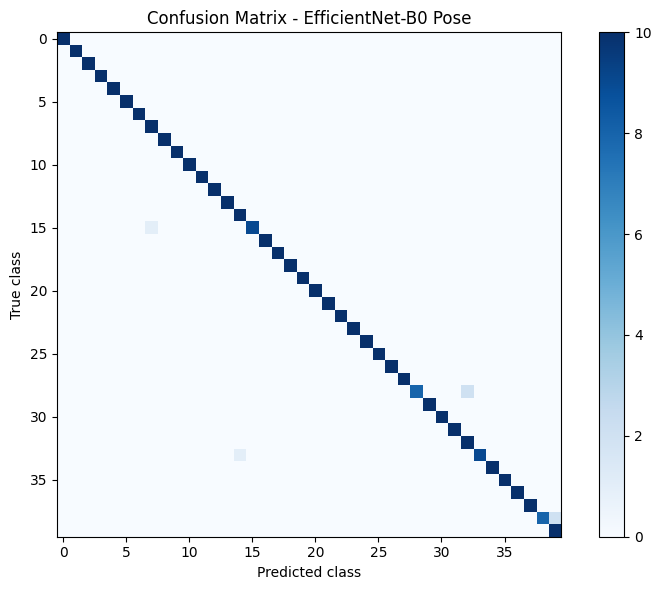

[EfficientNet-B0 Pose] Macro ROC AUC: 0.9999
[EfficientNet-B0 Pose] Macro PR AUC:  0.9975


{'accuracy': 0.985,
 'precision_macro': 0.9871212121212121,
 'recall_macro': 0.985,
 'f1_macro': 0.9848864585706691,
 'roc_auc_macro': 0.9998525641025641,
 'pr_auc_macro': 0.9975097962382445,
 'confusion_matrix': array([[10,  0,  0, ...,  0,  0,  0],
        [ 0, 10,  0, ...,  0,  0,  0],
        [ 0,  0, 10, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ..., 10,  0,  0],
        [ 0,  0,  0, ...,  0,  8,  2],
        [ 0,  0,  0, ...,  0,  0, 10]], dtype=int64)}

In [ ]:
# definig efficientnet B0  modified model for pose classification
class PoseClassifierEfficientNetB0(nn.Module):  # class for custom model
    def __init__(self, num_classes):            # constructor/ initializtion function taking input as 40 classes
        super().__init__()                      # initialzing parent module
        
        # loadinign oretrained model weights from torch visison 
        self.backbone = models.efficientnet_b0(  # creating pretrained model
            weights=models.EfficientNet_B0_Weights.DEFAULT  # imageNet weights
        )
        
        # modyfying the final classification layers
    
        in_features = self.backbone.classifier[1].in_features  # get input feature size in efficient net -b0
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)  # replace final output layer to 40 classes
    
    def forward(self, x):# define the forward pass
        return self.backbone(x) # runs through backbone and rerurns logits


# creatining model instance using class
model_effb0 = PoseClassifierEfficientNetB0(num_classes=num_classes).to(device) # move to device
print(model_effb0.backbone.classifier)  # printing backbone

# training with predefined fucntion as stated before 
train_hist_effb0, val_hist_effb0, best_val_effb0 = train_pose_model(  # stores validation and trainign history
    model_effb0, # model to train
    train_loader, # DataLoader providing training batches
    val_loader, # DataLoader providing validation batches
    device,  # device used for computation CPU or Cuda
    num_epochs=15, # same as other models for fair comparision
    lr=1e-3 # learning rate set the samw for fair comparision
)

# plotting curves as simialr to resnet models
plot_training_curves( # helper fucntion as defined before with inputs of previously stored training, validation history
    train_hist_effb0,     # training history values
    val_hist_effb0,       # validation history values
    title_prefix="EfficientNet-B0 Pose"  # title 
)

# testing phase
metrics_effb0 = evaluate_pose_model(  # evaluate model using helper function
    model_effb0,  # trained model
    test_loader,# test set data laoder
    device, # device for evaluation
    num_classes=num_classes, # number of classes for calculation of metrics and confucion matrix plotting
    model_name="EfficientNet-B0 Pose" # name for title
)

metrics_effb0  # retunr and display computed metrics

### 4. Fusion Model (ResNet-18+EfficientNet-B0) Implementation

After implementing the three model, it was observed that ResNet-18 and EfficientNet-B0 performed the best. Further, it can also be seen that both th emodels performed well on different classes. Through K.Ahmad et al. (2020) reference, a fusion model with combined weights with both the models was created.

In [ ]:
"""
Reference / conceptual inspiration for deep feature fusion:

K. Ahmad, K. Khan, and A. Al-Fuqaha,
“Intelligent Fusion of Deep Features for Improved Waste Classification,”
IEEE Access, vol. 8, pp. 96495–96504, 2020.

This work motivates the fusion of deep features extracted from multiple
CNN backbones, followed by joint classification using a shared fully
connected layer.
"""

In [ ]:
import torch.optim as optim #importing optimizers (Adam)

class FusionEffResNet(nn.Module):# defining class for initialization of modified model
    def __init__(self, num_classes, pretrained=True, freeze_backbones=False):# construtor for backbone for modified model
        super().__init__()# initialize the parent module
        
        # 1. EfficientNet-B0 weights 
        self.eff = models.efficientnet_b0(# load from torchvisison as detailed in pervious kernels
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None  # ImageNet weights
        )
        # modify final layer
        eff_in_features = self.eff.classifier[1].in_features  # rea dinput feature size of EfficientNet Model default 1280
        self.eff.classifier = nn.Identity()# replace with identity so model outputs feature vetor instead of logits for concatenation
        
        # 2. ResNet-18 backbone
        self.res = models.resnet18(  #load ResNet-18 from torchvision
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None  # ImageNet pretrained weights
        )
        # replace final fully connceted layer
        res_in_features = self.res.fc.in_features  # read input feature size 512
        self.res.fc = nn.Identity()  # replace final layer with identity so that models output features for concatenation
        
        fusion_input_dim = eff_in_features + res_in_features  # add both feautes 512 +1280
        
        # Optionally freeze backbones
        if freeze_backbones:# check whether freezing is requested
            for p in self.eff.parameters():# loop through all EfficientNet parameters
                p.requires_grad = False  # disable gradient computation for EfficientNet (prevents updating its weights)
            for p in self.res.parameters():# loop through all ResNet parameters
                p.requires_grad = False # disable gradient computation for ResNet (prevents updating its weights)
        
        #3. Fusion classifier layer
        self.fusion_head = nn.Sequential(# simialr to previous implementations
            nn.Linear(fusion_input_dim, 512),  # first layer 1792 -> 512 (same as efficientNet implentation)
            nn.ReLU(inplace=True),  # using ReLU activation
            nn.Dropout(p=0.4),  # dropout initialized as detailed 
            nn.Linear(512, num_classes)  # final layer to output logits for 512-> 40 classes
        )
    
    def forward(self, x):  # define forward pass given input batch x
        # x: (B, 3, 224, 224)  # expected input shape: batch size B, 3 color channels, 224x224 images
        feat_eff = self.eff(x)           # (B, 1280)  # extract EfficientNet feature vector for each image
        feat_res = self.res(x)           # (B, 512)  # extract ResNet feature vector for each image
        fused = torch.cat([feat_eff, feat_res], dim=1)  # (B, 1792)  # concatenate features along feature dimension
        logits = self.fusion_head(fused) # (B, num_classes)  # pass fused features through fusion head to get class scores
        return logits  # return logits (unnormalized scores) for loss/metrics

# creating an instance using the clss constructor
fusion_model = FusionEffResNet(num_classes=num_classes, pretrained=True, freeze_backbones=False).to(device) #move to device
print(fusion_model) # printing model to view layers

Using device: cpu
Number of pose classes: 40
FusionEffResNet(
  (eff): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activatio

In [ ]:
criterion_fusion = nn.CrossEntropyLoss() # cross entropy loss as initialized for other fucntions
# using the same optimizer function as for other parameters
optimizer_fusion = optim.Adam(
    fusion_model.parameters(), 
    lr=1e-3, # learning rate ste the same for fair comparison
)

num_epochs = 15 # number of epochs set the same for training
best_val_acc = 0.0
best_state_fusion = None

train_hist_fusion = {"loss": [], "acc": []}
val_hist_fusion   = {"loss": [], "acc": []}
#traning for each epoch and storing validation and training loss
for epoch in range(1, num_epochs + 1):
    # using predefined helper fucntion
    train_loss, train_acc = train_one_epoch_pose(
        fusion_model, train_loader, optimizer_fusion, criterion_fusion, device
    )
    #evaluation usingin validation using predefined helper fucntion
    val_loss, val_acc = evaluate_pose(
        fusion_model, val_loader, criterion_fusion, device
    )
    #storingin trainign and validation losses
    train_hist_fusion["loss"].append(train_loss)
    train_hist_fusion["acc"].append(train_acc)
    val_hist_fusion["loss"].append(val_loss)
    val_hist_fusion["acc"].append(val_acc)
    # ensuring the best validation accuracy is updated in eery epoch
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_fusion = fusion_model.state_dict()
    # printin trainng nad validation history for monitoring the traning
    print(f"Epoch {epoch:02d}/{num_epochs} "
          f"| Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
          f"| Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
# printing bets validation accuracy from training
if best_state_fusion is not None:
    fusion_model.load_state_dict(best_state_fusion)
    print(f"\nLoaded best fusion model with val acc = {best_val_acc:.4f}")

Epoch 01/15 | Train loss: 2.3999, acc: 0.2952 | Val loss: 2.4275, acc: 0.3966
Epoch 02/15 | Train loss: 0.8859, acc: 0.6694 | Val loss: 0.7615, acc: 0.7284
Epoch 03/15 | Train loss: 0.5416, acc: 0.8067 | Val loss: 0.2757, acc: 0.8990
Epoch 04/15 | Train loss: 0.3572, acc: 0.8783 | Val loss: 0.1232, acc: 0.9663
Epoch 05/15 | Train loss: 0.1646, acc: 0.9433 | Val loss: 0.0658, acc: 0.9736
Epoch 06/15 | Train loss: 0.1804, acc: 0.9433 | Val loss: 0.2616, acc: 0.9111
Epoch 07/15 | Train loss: 0.2423, acc: 0.9227 | Val loss: 0.5172, acc: 0.8606
Epoch 08/15 | Train loss: 0.1560, acc: 0.9622 | Val loss: 0.0308, acc: 0.9880
Epoch 09/15 | Train loss: 0.0797, acc: 0.9737 | Val loss: 0.0431, acc: 0.9832
Epoch 10/15 | Train loss: 0.0958, acc: 0.9696 | Val loss: 0.0145, acc: 1.0000
Epoch 11/15 | Train loss: 0.1319, acc: 0.9622 | Val loss: 0.1374, acc: 0.9471
Epoch 12/15 | Train loss: 0.0831, acc: 0.9753 | Val loss: 0.0280, acc: 0.9904
Epoch 13/15 | Train loss: 0.0328, acc: 0.9910 | Val loss: 0.0121

In [ ]:
# printing evaluation metrics for fusion model using predefined fucntion
test_loss, test_acc = evaluate_pose(
    fusion_model, test_loader, criterion_fusion, device
)
print(f"Fusion EffNetB0+ResNet18 | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

Fusion EffNetB0+ResNet18 | Test loss: 0.0280, Test acc: 0.9904


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# getting predictions, labels from the model using predefined helper fucntion
y_pred_fusion, y_true_test, probs_fus = get_preds_labels_probs(fusion_model, test_loader, device)

# computing the accuracy, precision ad recall of the test data 
acc = accuracy_score(y_true_test, y_pred_fusion)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true_test, y_pred_fusion,
    average="macro",
    zero_division=0
)

print("Fusion EffNetB0 + ResNet18 – Test metrics")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro):    {rec:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

print("\nDetailed classification report:")
print(classification_report(y_true_test, y_pred_fusion, zero_division=0))


Fusion EffNetB0 + ResNet18 – Test metrics
Accuracy: 0.9900
Precision (macro): 0.9913
Recall (macro):    0.9900
F1-score (macro):  0.9899

Detailed classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       0.91      1.00      0.95        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       1.00      0.90      0.95        10
          14       

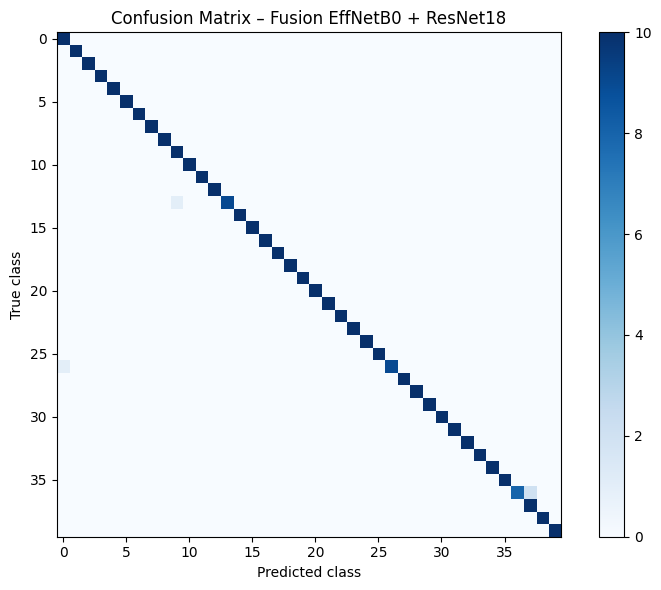

In [ ]:
#plotting confusion matrix of the fusion model 
cm_fusion = confusion_matrix(y_true_test, y_pred_fusion)

plt.figure(figsize=(8, 6))
plt.imshow(cm_fusion, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix – Fusion EffNetB0 + ResNet18")
plt.colorbar()
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

### Optimization and Regularization - Hyperparameter Tuning for best model

Grid search through:
learning rates = [1e-3, 3e-4, 1e-4] (with a slight decay in learning rate to help with better generalization - as the fusion model has a lot of features it can overfit) and
dropout rates = [0.3, 0.4, 0.5]

In [ ]:
"""
Reference / inspiration for hyperparameter tuning (grid search):

Hammad.ai (Medium).
“Using Grid Search for Hyper-Parameter Tuning”.
https://medium.com/@hammad.ai/using-grid-search-for-hyper-parameter-tuning-bad6756324cc

Additional references:
- scikit-learn documentation (GridSearchCV / model selection):
  https://scikit-learn.org/stable/modules/grid_search.html
"""

In [ ]:
# intializing backbone exactly as done previosuly for tuning the hyper parameters of the fusion model - but for only 8 epochsand grid search
class FusionEffResNet(nn.Module):
    def __init__(self, num_classes, pretrained=True, freeze_backbones=False, dropout_p=0.4):
        super().__init__()
        
        # EfficientNet-B0 backbone
        self.eff = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )
        eff_in_features = self.eff.classifier[1].in_features  # 1280
        self.eff.classifier = nn.Identity()
        
        # ResNet18 backbone
        self.res = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        res_in_features = self.res.fc.in_features  # 512
        self.res.fc = nn.Identity()
        
        fusion_input_dim = eff_in_features + res_in_features  # 1792
        
        if freeze_backbones:
            for p in self.eff.parameters():
                p.requires_grad = False
            for p in self.res.parameters():
                p.requires_grad = False
        

        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_input_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        feat_eff = self.eff(x)   # (B, 1280)
        feat_res = self.res(x)   # (B, 512)
        fused = torch.cat([feat_eff, feat_res], dim=1)  # (B, 1792)
        logits = self.fusion_head(fused)
        return logits


#### Helper Function for training with different parameters

In [ ]:
#function: train model with given parameters learning rate, dropout rate, and number of epochs =8
#return best validation accuracy obtained from tuning with specified parameters
def train_fusion_with_hparams(lr, dropout_p, weight_decay=0.0, num_epochs=8):
    #creatingin instance of th emodel with constrcutor
    model = FusionEffResNet(
        num_classes=num_classes,
        pretrained=True,
        freeze_backbones=False,
        dropout_p=dropout_p
    ).to(device)
    # loss fucntion as cross entropy - used for classification
    criterion = nn.CrossEntropyLoss()
    # Adam Optimization with learning rate as specified
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay  # 0.0 weight decay 
    )

    scheduler = optim.lr_scheduler.StepLR(  # creatingin scheduler that decays the learning rate
        optimizer, # optimizer whose learning rate will be modified by the scheduler
        step_size=5,# number of epochs between each LR decay step
        gamma=0.5 # multiplicative factor of LR decay 
    ) # end of scheduler configuration
    
    best_val_acc = 0.0 # track the best validation accuracy observed across all epochs
    
    for epoch in range(1, num_epochs + 1): # training
        #using predefined fucntion to train each epoch and return teh traingin loss
        train_loss, train_acc = train_one_epoch_pose(  
            model, train_loader, optimizer, criterion, device  # 
        )  
        # predefined fucntion to retunr validation loss
        val_loss, val_acc = evaluate_pose( 
            model, val_loader, criterion, device #pass validation data loader model to the fucntion
        )
        scheduler.step() #update according to scheduler
        
        if val_acc > best_val_acc: 
            best_val_acc = val_acc                       # update best validation accuracy
        
        print(f"[lr={lr:.0e}, drop={dropout_p}] "         # print hyperparameters used (learning rate + dropout prob)
              f"Epoch {epoch:02d}/{num_epochs} "         # print epoch counter in 2-digit format and total epochs
              f"| Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "  # print training loss/accuracy (4 decimals)
              f"| Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")        # print validation loss/accuracy (4 decimals)
    
    print(f"Best val acc for lr={lr:.0e}, dropout={dropout_p}: {best_val_acc:.4f}\n")  # print best val accuracy achieved
    return best_val_acc                         # return best validation accuracy (useful for hyperparameter selection)

In [ ]:

lr_list = [1e-3, 3e-4, 1e-4] # creatining lists for grid serach over potential parameter values for learning and drop out rates
dropout_list = [0.3, 0.4, 0.5]

results = {} # dictionary fr storing results
#iratingin through each learning rate
for lr in lr_list:
    for drop in dropout_list: # inner loop iterates through dropout rate
        print(f"=== Tuning lr={lr}, dropout={drop} ===") # prinitng current learnign and dropout rate
        best_val = train_fusion_with_hparams(lr=lr, dropout_p=drop, num_epochs=8) # computing best validation accuracy and printing epochs with helper fucntion
        results[(lr, drop)] = best_val # results stored in dictionary

print("Validation results (lr, dropout) -> best val acc:") # printing best validation accuracy (full result) - title
# each (lr,drop) rates in the dictionary
for (lr, drop), score in results.items():
    print(f"  lr={lr:.0e}, dropout={drop}: {score:.4f}") # printing their corresponding scores

best_lr, best_drop = max(results, key=results.get) # extracting the maximum accurcay form the dictionary 
print(f"\nChosen hyperparameters: lr={best_lr:.0e}, dropout={best_drop}") # printing chosen hyper parameters

=== Tuning lr=0.001, dropout=0.3 ===
[lr=1e-03, drop=0.3] Epoch 01/8 | Train loss: 2.4382, acc: 0.2837 | Val loss: 1.7225, acc: 0.4856
[lr=1e-03, drop=0.3] Epoch 02/8 | Train loss: 0.8213, acc: 0.6982 | Val loss: 0.4774, acc: 0.8125
[lr=1e-03, drop=0.3] Epoch 03/8 | Train loss: 0.4268, acc: 0.8429 | Val loss: 0.2817, acc: 0.8846
[lr=1e-03, drop=0.3] Epoch 04/8 | Train loss: 0.3265, acc: 0.8906 | Val loss: 0.2830, acc: 0.8942
[lr=1e-03, drop=0.3] Epoch 05/8 | Train loss: 0.2510, acc: 0.9178 | Val loss: 0.3356, acc: 0.8894
[lr=1e-03, drop=0.3] Epoch 06/8 | Train loss: 0.1298, acc: 0.9605 | Val loss: 0.0207, acc: 0.9952
[lr=1e-03, drop=0.3] Epoch 07/8 | Train loss: 0.0472, acc: 0.9877 | Val loss: 0.0141, acc: 0.9952
[lr=1e-03, drop=0.3] Epoch 08/8 | Train loss: 0.0264, acc: 0.9934 | Val loss: 0.0375, acc: 0.9808
Best val acc for lr=1e-03, dropout=0.3: 0.9952

=== Tuning lr=0.001, dropout=0.4 ===
[lr=1e-03, drop=0.4] Epoch 01/8 | Train loss: 2.5047, acc: 0.2870 | Val loss: 1.2377, acc: 0.5

#### Retraining Pose classifcation fusion model with chosen parameters

In [ ]:
#creatining an instanceof the model
fusion_model_final = FusionEffResNet(
    num_classes=num_classes,
    pretrained=True,
    freeze_backbones=False,
    dropout_p=best_drop
).to(device)
# loss fucntion = crossentropy
criterion_fusion = nn.CrossEntropyLoss()
#optimizer set as Adam as before
optimizer_fusion = optim.Adam(
    fusion_model_final.parameters(),
    lr=best_lr,
    weight_decay=0.0  
)
# sceduler for weight decay as before
scheduler_fusion = optim.lr_scheduler.StepLR(
    optimizer_fusion,
    step_size=5,
    gamma=0.5
)
# number of epoch increased for properfull trainign for fair comparision
num_epochs = 15
best_val_acc = 0.0
best_state_fusion = None
# storingin trainign and validation history in a dictionary
train_hist_fusion = {"loss": [], "acc": []}
val_hist_fusion   = {"loss": [], "acc": []}
#traingin for 15 epochs
for epoch in range(1, num_epochs + 1):
    #traingin each epoch with predefined fuction that returns trainign accurcay
    train_loss, train_acc = train_one_epoch_pose(
        fusion_model_final, train_loader, optimizer_fusion, criterion_fusion, device
    )
    val_loss, val_acc = evaluate_pose(
        fusion_model_final, val_loader, criterion_fusion, device
    )
    scheduler_fusion.step()
    #appending values for 15 epcohs
    train_hist_fusion["loss"].append(train_loss)
    train_hist_fusion["acc"].append(train_acc)
    val_hist_fusion["loss"].append(val_loss)
    val_hist_fusion["acc"].append(val_acc)
    # strogin /updating best validation accurcay
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_fusion = fusion_model_final.state_dict()
    #pringtin numbe rof pochs and currect traingin anf validation loss and accuracy
    print(f"Epoch {epoch:02d}/{num_epochs} "
          f"| Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
          f"| Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
# printing best validation accuracy obtained
if best_state_fusion is not None:
    fusion_model_final.load_state_dict(best_state_fusion)
    print(f"\nLoaded best tuned fusion model with val acc = {best_val_acc:.4f}")

Epoch 01/15 | Train loss: 2.7700, acc: 0.3158 | Val loss: 1.3934, acc: 0.6034
Epoch 02/15 | Train loss: 0.8351, acc: 0.7516 | Val loss: 0.3963, acc: 0.8774
Epoch 03/15 | Train loss: 0.3318, acc: 0.9062 | Val loss: 0.1744, acc: 0.9471
Epoch 04/15 | Train loss: 0.1573, acc: 0.9597 | Val loss: 0.0883, acc: 0.9832
Epoch 05/15 | Train loss: 0.0889, acc: 0.9786 | Val loss: 0.0506, acc: 0.9808
Epoch 06/15 | Train loss: 0.0364, acc: 0.9942 | Val loss: 0.0110, acc: 0.9976
Epoch 07/15 | Train loss: 0.0191, acc: 0.9984 | Val loss: 0.0114, acc: 0.9976
Epoch 08/15 | Train loss: 0.0103, acc: 1.0000 | Val loss: 0.0040, acc: 1.0000
Epoch 09/15 | Train loss: 0.0084, acc: 1.0000 | Val loss: 0.0037, acc: 1.0000
Epoch 10/15 | Train loss: 0.0069, acc: 1.0000 | Val loss: 0.0038, acc: 1.0000
Epoch 11/15 | Train loss: 0.0074, acc: 1.0000 | Val loss: 0.0031, acc: 1.0000
Epoch 12/15 | Train loss: 0.0051, acc: 1.0000 | Val loss: 0.0034, acc: 1.0000
Epoch 13/15 | Train loss: 0.0044, acc: 1.0000 | Val loss: 0.0035

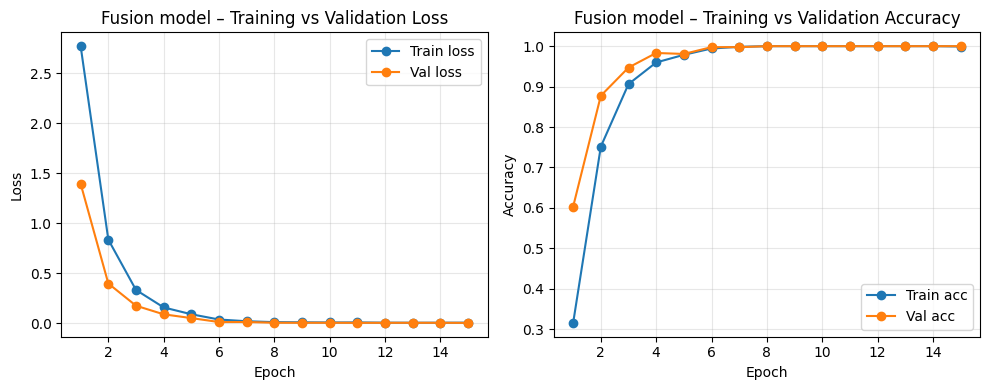

In [ ]:
import matplotlib.pyplot as plt
# length vs. width of plot epochs vs. lenght of trainign loss
epochs = range(1, len(train_hist_fusion["loss"]) + 1)

plt.figure(figsize=(10, 4))

# plotting loss curve for tranign and validation
plt.subplot(1, 2, 1)
plt.plot(epochs, train_hist_fusion["loss"], marker="o", label="Train loss")
plt.plot(epochs, val_hist_fusion["loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fusion model – Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# plotting accuracy curve for traingin and validation
plt.subplot(1, 2, 2)
plt.plot(epochs, train_hist_fusion["acc"], marker="o", label="Train acc")
plt.plot(epochs, val_hist_fusion["acc"], marker="o", label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fusion model – Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TUNED Fusion EffNetB0 + ResNet18 – Test metrics
Accuracy: 0.9950
Precision (macro): 0.9958
Recall (macro):    0.9950
F1-score (macro):  0.9949


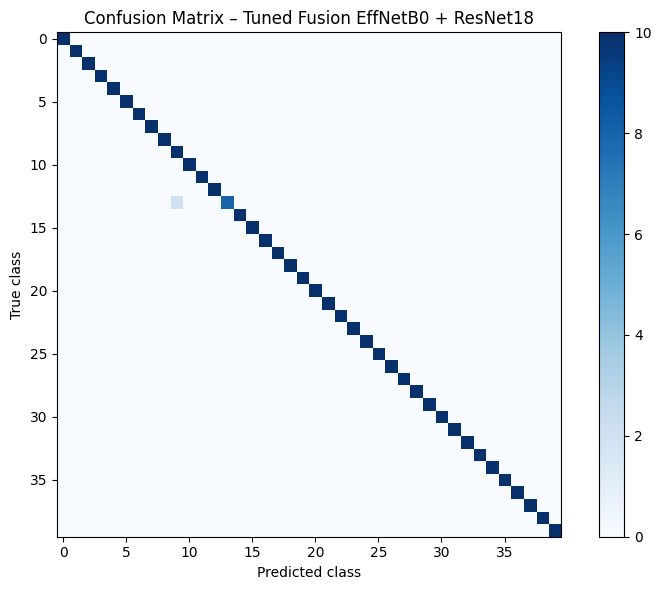

In [ ]:
# getting predictions and labels for plotting confusion matrix
y_pred_fusion, y_true_test, probs_fus= get_preds_labels_probs(fusion_model_final, test_loader, device)
# computing accurcay, precision recall and F1 score as done in previos funsion model
acc = accuracy_score(y_true_test, y_pred_fusion)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true_test, y_pred_fusion,
    average="macro",
    zero_division=0
)

# printing final TUNED fusion model confusion matrix and evaluation metrics
print("TUNED Fusion EffNetB0 + ResNet18 – Test metrics")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro):    {rec:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

cm_fusion = confusion_matrix(y_true_test, y_pred_fusion)

plt.figure(figsize=(8, 6))
plt.imshow(cm_fusion, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix – Tuned Fusion EffNetB0 + ResNet18")
plt.colorbar()
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Depth Estimation

1.ResNet-18

2.ResNet-50

3.EfficientNet-B0

4.Fusion Model (Res+Eff)

### Helper Functions for Training, Testing and Plotting 

In [ ]:
#function: to compute RMSE using orginal depth values (not standardized)
# inputs: predicted depth, target depth, mean and standard deviation (as z-score normalization was used)
# output: RMSE values using normal depth
def rmse_from_normalised(pred_norm, target_norm, mean, std): 
    if isinstance(pred_norm, torch.Tensor):# check if pred_norm is a PyTorch tensor
        pred_norm = pred_norm.detach().cpu().numpy()# if it is then it is detached from the graph or moved to CPU
    if isinstance(target_norm, torch.Tensor):# check if target_norm is a PyTorch tensor
        target_norm = target_norm.detach().cpu().numpy() # do the same 
    
    pred = pred_norm * std + mean  # de-nrmalize it based on z-score
    target = target_norm * std + mean # denormalize the target values based on zscore to ensure accuracte RMSE
    mse = np.mean((pred - target) ** 2) #compute mean squared error between predicted and taget
    return float(np.sqrt(mse))# return its squareroot (RMSE) as s float


@torch.no_grad() #disbale gradient tracking
# function for getting true and predicted values for curve plotting for evaluation
#input: model for evaluation, dataloader for testing, devce, depth mean and standard deviation for denormalization
# returns: true and predicted depths
def get_depth_predictions(model, dataloader, device, depth_mean, depth_std): 
    model.eval() # set model to evaluation mode
    all_pred_norm = []# list to store predicted depth values (normalized)
    all_true_norm = []# list to store true depth values (normalized)
    
    for images, pose_labels, depths_norm in dataloader:# iterate over batches in the data loader
        images = images.to(device) #move images to device
        depths_norm = depths_norm.to(device).float()#move depth values to device
        
        preds_norm = model(images)#predict normalized depths for each image
        
        all_pred_norm.append(preds_norm.detach().cpu()) #append the predictions
        all_true_norm.append(depths_norm.detach().cpu()) # detach move to cpu and append to list of true depth values
    
    all_pred_norm = torch.cat(all_pred_norm)# concatenate all the batches it was evaluated on into one tesnsor for predicted values
    all_true_norm = torch.cat(all_true_norm)# concatenate all the batches it was evaluated on into one tesnsor for true values
    
   # convert to original values, as done previously
    y_pred = all_pred_norm.numpy() * depth_std + depth_mean# denormalize predicted
    y_true = all_true_norm.numpy() * depth_std + depth_mean# denormalize true after converting to numpy
    
    return y_true, y_pred # return list of original units for evaluation/ plotting

# function: training model for one epoch while storing traingin loss and rmse 
#inputss: model, training data loader, optimizer, criterion(loss fucntion), device, depth mean and standard deviation to ensure the values are denormalized 
# retunrs mean rmse and traingin loss for that epoch
def train_one_epoch_depth(model, dataloader, optimizer, criterion, device, depth_mean, depth_std):
    model.train()# set model to training mode to ensure drop outs batch normalization and all are turned on
    running_loss = 0.0 # incrementor for train loss
    running_rmse = 0.0 # increments rmse values
    total_batches = 0 # counts batches 
    #for each image in the data loader , iterate over batches
    for images, pose_labels, depths_norm in dataloader: 
        images = images.to(device) #move images to device
        depths_norm = depths_norm.to(device).float()#move normalized depths to device
        
        optimizer.zero_grad()#clear existing gradients from previous iteration
        
        preds_norm = model(images)  #forward pass to compute current intermediate values
        loss = criterion(preds_norm, depths_norm)#compute loss using loss_fucntion specified in teh input parameters
        loss.backward() #backpropogation to comput new weights
        optimizer.step()#update model parameters using the optimizer fucntion specified in th einput parameters
        
        batch_rmse = rmse_from_normalised(# compute rmse from this batch using previous helper fucntion
            preds_norm, depths_norm, depth_mean, depth_std #pass true and predicted values of depth stored
        )
        
        running_loss += loss.item()#add batch trainng loss for th eone epoch to the incrementor
        running_rmse += batch_rmse # add rmse to the incremntor defined earliers
        total_batches += 1 #increment the batches by 1
    
    return running_loss / total_batches, running_rmse / total_batches# return average running loss and rmse 

#function: evaluation fucntion for validation or test
#inputs: model, data, loss fucntion, devide, depth meand nad standard deviation
#returns average validation loss and rmse 
@torch.no_grad()#disable gradient tracking for evaluation
def evaluate_depth(model, dataloader, criterion, device, depth_mean, depth_std): 
    model.eval()#set model to evaluation model
    running_loss = 0.0 #acccumulator for validation loss
    running_rmse = 0.0 #accumulator for rmse
    total_batches = 0 #incrementor for batches
    
    for images, pose_labels, depths_norm in dataloader: #iterate over batches
        images = images.to(device)#move images to device9cpu
        depths_norm = depths_norm.to(device).float()#move depth normalized to device and convert to float
        
        preds_norm = model(images)#formward pass to predict depth value 
        loss = criterion(preds_norm, depths_norm)#compute loss using loss fucntion
        
        batch_rmse = rmse_from_normalised(#compute rse in the overall batch using predefined fucntion to get denormalized rmse value
            preds_norm, depths_norm, depth_mean, depth_std # input preducted and true values
        ) 
        
        running_loss += loss.item() #sum with validation loss for each batch
        running_rmse += batch_rmse #sum with validation rmse for each batch
        total_batches += 1#increment batch counter by 1
    
    return running_loss / total_batches, running_rmse / total_batches # return denormalized men rmse and validation loss

#function: plotting loss and rmse curves for trainign and validation over th eepochs
#input: traingin history and validation history over th eepochs and title 
def plot_loss_rmse_curves(train_hist, val_hist, title_prefix="Model"):
    epochs = range(1, len(train_hist["loss"]) + 1) #create index based on loss lenght
    plt.figure(figsize=(10,4))#specifying plot size
#plotting validation and training loss curves over the epochs on the left
    plt.subplot(1, 2, 1) 
    plt.plot(epochs, train_hist["loss"], label="Train") 
    plt.plot(epochs, val_hist["loss"], label="Val") 
    plt.xlabel("Epoch")
    plt.ylabel("MSE (normalised)")
    plt.title(f"{title_prefix} – Loss") 
    plt.legend()

    # RMSE validation and trainign on the right
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_hist["rmse"], label="Train RMSE") 
    plt.plot(epochs, val_hist["rmse"], label="Val RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE (original units)")  
    plt.title(f"{title_prefix} – RMSE")  
    plt.legend()   

    plt.tight_layout() #adjust space
    plt.show() #display

# function: plotting a scatter plot of true and predicted depth values (residual) to look for patterns
# input: true and precited values and title
def plot_true_vs_pred_depth(y_true, y_pred, title="Depth: True vs Predicted"):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.4, s=10) 
    lims = [# computnig axis to cover minimum and maximum ranges of the values
        min(y_true.min(), y_pred.min()),#lowe limit
        max(y_true.max(), y_pred.max())#upper limit
    ]
    #plotting the scatter plot of pred vs true
    plt.plot(lims, lims, 'r--', linewidth=1)  # ideal line (a diagonal) plotted for comparision or deviation form line
    plt.xlabel("True depth") 
    plt.ylabel("Predicted depth")
    plt.title(title)
    plt.tight_layout() 
    plt.show() 

#Funtion: plots depth error histrogram to look for patters and error analysis
#inputs: predicted, true and title
def plot_depth_error_histogram(y_true, y_pred, title="Depth prediction error"):
    errors = y_pred - y_true #comput residuals
    plt.figure(figsize=(6,4))# defined plot size
    plt.hist(errors, bins=30, alpha=0.7) # 30 bins error differe over 30 points in range
    plt.xlabel("Prediction error (pred - true)") 
    plt.ylabel("Count") 
    plt.title(title)
    plt.tight_layout() #adjust spacing
    plt.show() #display histogram
#function: compute R^2 based on true nad precicted values
#input: true and predicted
def r2_score_depth(y_true, y_pred): 
    y_true = np.asarray(y_true)#ensure turee values are in an array
    y_pred = np.asarray(y_pred)#ensure predicted values are in an array

    ss_res = np.sum((y_true - y_pred) ** 2)#compute residual sum of sqaures
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)#compute total sum of squares(base line model avergaing output)

    return 1 - (ss_res / ss_tot + 1e-8) #return R^2 with small epsilon to avoid zero dvision

### 1. ResNet-18 Model Implementation

In [ ]:
"""
Reference / inspiration for image-based regression using PyTorch:

Sagar Rathod (GitHub / Google Colab).
“Image Regression Example (PyTorch)”.
https://colab.research.google.com/github/sagar-rathod/PytorchDeepML/blob/master/examples/Image_Regression_Example.ipynb

Additional references:
- PyTorch Autograd and Loss Functions:
  https://pytorch.org/docs/stable/autograd.html
  https://pytorch.org/docs/stable/nn.html#loss-functions
- PyTorch Tutorials (training loops and evaluation):
  https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
"""

[ResNet18Depth] Epoch 01/8 | Train loss: 0.2486, RMSE: 0.1491 | Val loss: 0.3022, RMSE: 0.1717
[ResNet18Depth] Epoch 02/8 | Train loss: 0.0936, RMSE: 0.0945 | Val loss: 0.0771, RMSE: 0.0860
[ResNet18Depth] Epoch 03/8 | Train loss: 0.0879, RMSE: 0.0887 | Val loss: 0.0243, RMSE: 0.0484
[ResNet18Depth] Epoch 04/8 | Train loss: 0.0677, RMSE: 0.0787 | Val loss: 0.0727, RMSE: 0.0843
[ResNet18Depth] Epoch 05/8 | Train loss: 0.0619, RMSE: 0.0756 | Val loss: 0.0335, RMSE: 0.0571
[ResNet18Depth] Epoch 06/8 | Train loss: 0.0563, RMSE: 0.0719 | Val loss: 0.0315, RMSE: 0.0553
[ResNet18Depth] Epoch 07/8 | Train loss: 0.0469, RMSE: 0.0662 | Val loss: 0.0188, RMSE: 0.0426
[ResNet18Depth] Epoch 08/8 | Train loss: 0.0480, RMSE: 0.0663 | Val loss: 0.0179, RMSE: 0.0413

Loaded best ResNet18Depth with val RMSE = 0.0413
ResNet18Depth | Test loss (MSE norm): 0.0173, Test RMSE: 0.0410


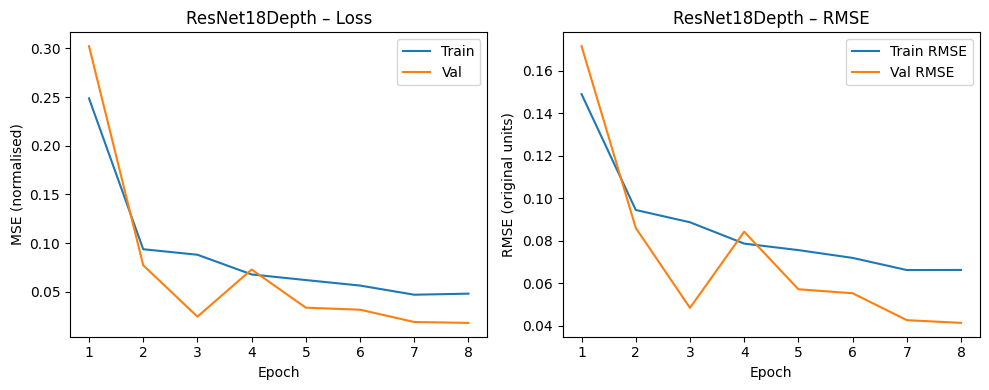

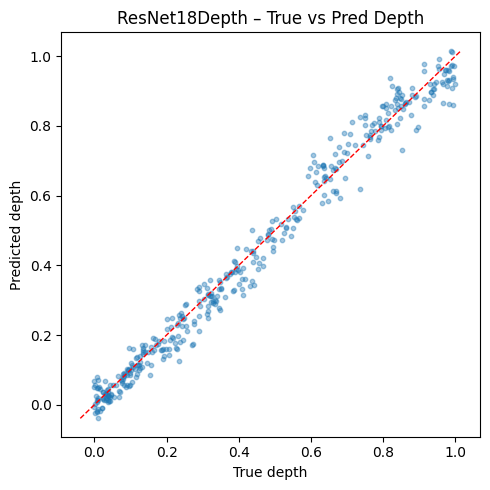

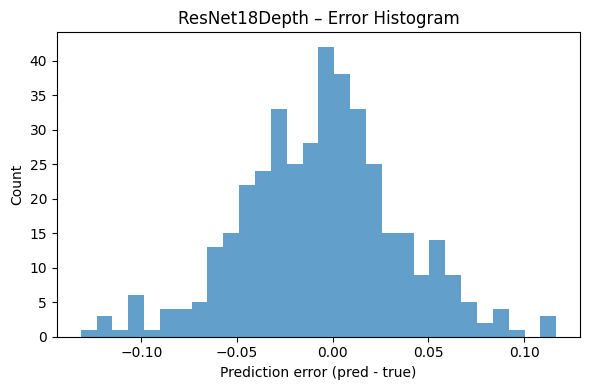

In [ ]:
class ResNet18Depth(nn.Module): #defining class for modified model for depth estimation
    def __init__(self, pretrained=True):
        super().__init__() # parent
        self.backbone = models.resnet18( # extracting model weights from torch visison resnet-18 pretrained on imagenet 
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        # input features from back bone in pretrained resnet-18 model
        in_features = self.backbone.fc.in_features  # 512
        self.backbone.fc = nn.Sequential( # modifying final layer 
            nn.Linear(in_features, 256), # mapping input features 256 as done in previous for pose estimation (captures enough features wo overfitting)
            nn.ReLU(inplace=True), # activation fucntion set as RELU to prevent gradient vanishing
            nn.Dropout(p=0.3), # dropout rate set to 0.3 as stated in th ereport
            nn.Linear(256, 1) # final layer mapped from 256 features to 1 output for regression
        )
    def forward(self, x): #define forward pass fucntion
        out = self.backbone(x)  # out put is a pass of 1D pedictions
        return out.squeeze(1)   # remoce dimension 1 for convenience while computing metrics


model_depth_resnet18 = ResNet18Depth(pretrained=True).to(device)#create instance of ResNet depth model using class
criterion_depth = nn.MSELoss()# set loss fucntion as MSE
optimizer_depth_resnet18 = optim.Adam(model_depth_resnet18.parameters(), lr=1e-4) # Adam optimizer as optimization ufcntion with learning rate 1e-4

num_epochs = 8 #number of epochs set to 8, lower for depth as values converge fatser
best_val_rmse = float("inf")#best val rmse set to inf in the beggingin for storing the lowest rmse values
best_state_resnet18 = None #place holder to hold the model weights with the best rmse

train_hist_resnet18 = {"loss": [], "rmse": []} #dictionary for storing trainign loss
val_hist_resnet18   = {"loss": [], "rmse": []} #dictionary for storing validation loss per epoch

for epoch in range(1, num_epochs + 1): #loop over epochs 1-8
    train_loss, train_rmse = train_one_epoch_depth( #train one epoch using predefined fucntion to get training loss and rmse lostsfor the current epoch
        model_depth_resnet18, train_loader, optimizer_depth_resnet18,# give inputs model to train, train data loader, optimizer= adam
        criterion_depth, device, depth_mean_train, depth_std_train # loss function mse, device, depth mena dn standard deviation 
    )                                                    # end train_one_epoch_depth call
    val_loss, val_rmse = evaluate_depth(# evealuate model using predefined fucntion for teh validation fucntion to get validation loss and rmse
        model_depth_resnet18, val_loader,#pass model, validation data loader, loss fucntion=mse, device, standard deviation nad mean
        criterion_depth, device, depth_mean_train, depth_std_train     # provide loss function, device, and normalisation stats
    )  
    
    train_hist_resnet18["loss"].append(train_loss)# append trainign loss for current epoch
    train_hist_resnet18["rmse"].append(train_rmse)#append rmse for traingin current epoch
    val_hist_resnet18["loss"].append(val_loss)#append validation loss for current epoch
    val_hist_resnet18["rmse"].append(val_rmse)#append validation rmse for current epoch
    
    if val_rmse < best_val_rmse: #check if current rmse is lower
        best_val_rmse = val_rmse #update best rmse if it is 
        best_state_resnet18 = model_depth_resnet18.state_dict()#save the current model weigths
    
    print(f"[ResNet18Depth] Epoch {epoch:02d}/{num_epochs} " #print model and epochs for monitoring
          f"| Train loss: {train_loss:.4f}, RMSE: {train_rmse:.4f} "#print traingin loss upto 4 decimal points
          f"| Val loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}") #print validation rmse for upto 4 decimal points

if best_state_resnet18 is not None:#check if best state is saved
    model_depth_resnet18.load_state_dict(best_state_resnet18)  # load the best model
    print(f"\nLoaded best ResNet18Depth with val RMSE = {best_val_rmse:.4f}")  # print for confimation

# Evaluation on test set
test_loss, test_rmse = evaluate_depth( #compute rmse using helper fucntion predefined
    model_depth_resnet18, test_loader, #provide model, test data loader, loss fucntion = mse, device
    criterion_depth, device, depth_mean_train, depth_std_train 
)  
print(f"ResNet18Depth | Test loss (MSE norm): {test_loss:.4f}, Test RMSE: {test_rmse:.4f}")  # print test results of test loss and rmse

# Plotting rmse curves using predefined fucntion by providing traingin and validation history over epochs
plot_loss_rmse_curves(train_hist_resnet18, val_hist_resnet18, title_prefix="ResNet18Depth")

# get true and predicted depth values for plotting scatter plot for errror analysis
y_true_resnet18, y_pred_resnet18 = get_depth_predictions(
    model_depth_resnet18, test_loader, device, depth_mean_train, depth_std_train  # provide model, test data loader
) 
plot_true_vs_pred_depth(y_true_resnet18, y_pred_resnet18, title="ResNet18Depth – True vs Pred Depth")  #plotting predicted vs. true scatter ploy
plot_depth_error_histogram(y_true_resnet18, y_pred_resnet18, title="ResNet18Depth – Error Histogram")   #histogam of predicted errors

In [ ]:
# getiing true and predicted values using predefined fucntion
y_true_res18, y_pred_res18 = get_depth_predictions(
    model_depth_resnet18, test_loader, device,
    depth_mean_train, depth_std_train # provide test data, model
)
#compute R sqaured using predefined fucntion
test_r2 = r2_score_depth(y_true_res18, y_pred_res18)
print(f"Test R²: {test_r2:.4f}") # print value


Test R²: 0.9829


### 2. ResNet-50 Depth Implementation

In [ ]:
"""
Reference / inspiration for image regression using ResNet50:

National Institute of Standards and Technology (NIST).
“Image Regression with ResNet50”.
https://github.com/usnistgov/image-regression-resnet50

Additional references:
- PyTorch Vision ResNet models:
  https://pytorch.org/vision/stable/models.html
- PyTorch Loss Functions for Regression:
  https://pytorch.org/docs/stable/nn.html#loss-functions
- PyTorch Training and Evaluation Tutorials:
  https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
"""

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\adamj/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:04<00:00, 25.6MB/s]


[ResNet50Depth] Epoch 01/8 | Train loss: 0.2631, RMSE: 0.1490 | Val loss: 0.0515, RMSE: 0.0704
[ResNet50Depth] Epoch 02/8 | Train loss: 0.0837, RMSE: 0.0886 | Val loss: 0.0374, RMSE: 0.0596
[ResNet50Depth] Epoch 03/8 | Train loss: 0.0678, RMSE: 0.0791 | Val loss: 0.0349, RMSE: 0.0576
[ResNet50Depth] Epoch 04/8 | Train loss: 0.0552, RMSE: 0.0706 | Val loss: 0.0173, RMSE: 0.0407
[ResNet50Depth] Epoch 05/8 | Train loss: 0.0785, RMSE: 0.0848 | Val loss: 0.0205, RMSE: 0.0446
[ResNet50Depth] Epoch 06/8 | Train loss: 0.0762, RMSE: 0.0807 | Val loss: 0.0223, RMSE: 0.0463
[ResNet50Depth] Epoch 07/8 | Train loss: 0.0506, RMSE: 0.0682 | Val loss: 0.0887, RMSE: 0.0923
[ResNet50Depth] Epoch 08/8 | Train loss: 0.0473, RMSE: 0.0642 | Val loss: 0.0222, RMSE: 0.0466

Loaded best ResNet50Depth with val RMSE = 0.0407
ResNet50Depth | Test loss (MSE norm): 0.0227, Test RMSE: 0.0470
ResNet50Depth | Test R²: 0.9777


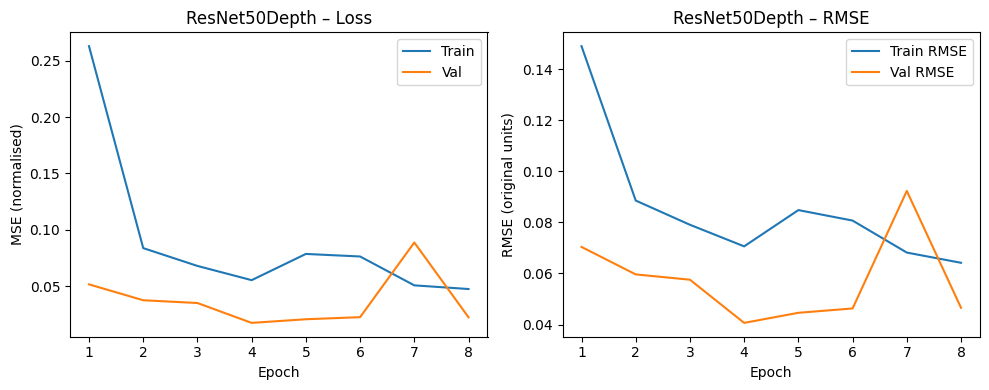

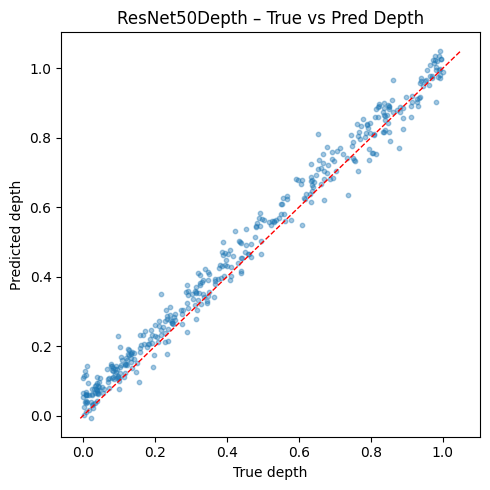

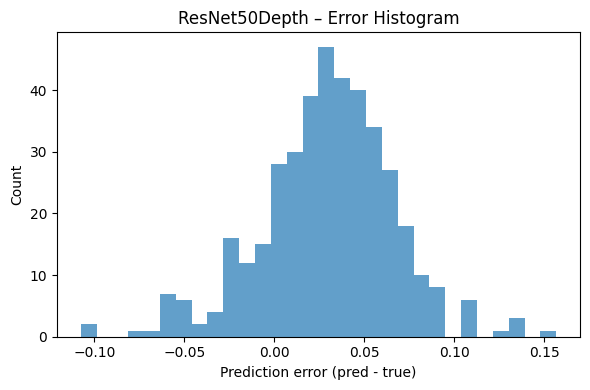

In [ ]:
# class for defining modified ResNet-50 
class ResNet50Depth(nn.Module):
    def __init__(self, pretrained=True): # constructor fucntion for modified model
        super().__init__() # parent
        self.backbone = models.resnet50( # extracting backbone from torchvision pretrained model weights 
            weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_features = self.backbone.fc.in_features  #input features stored in in_features
        self.backbone.fc = nn.Sequential( # modifying final layer for depth regression
            nn.Linear(in_features, 512), # mappting input features in pretrained in 512 as done previously
            nn.ReLU(inplace=True), # ReLU activation to prevent vanishing gradient
            nn.Dropout(p=0.3),# droput out rate set to 0.3 asdetailed in te report
            nn.Linear(512, 1)   # outputs scalar normalized depth prediction
        )
    # forward pass fucntion 
    def forward(self, x):
        out = self.backbone(x)  # out put a 1D
        return out.squeeze(1)   # # remove dimension 1 for convenience while computing metrics
    
# create model instance using class 
model_depth_resnet50 = ResNet50Depth(pretrained=True).to(device)
criterion_depth = nn.MSELoss() # MSE loss as loss fucntion
optimizer_depth_resnet50 = optim.Adam(model_depth_resnet50.parameters(), lr=1e-4) # same optimizer with learning rate 1e-4 for fair comparison

# Training loop set to 8 epochs as detailed previosly
num_epochs = 8
best_val_rmse = float("inf") # best validation rmse place holder
best_state_resnet50 = None # best weights place holder (model witn lowest validation rmse)

train_hist_resnet50 = {"loss": [], "rmse": []} # dictionary for string traingin history rmse and loss
val_hist_resnet50   = {"loss": [], "rmse": []} # dictionary for validation history rmse and loss

for epoch in range(1, num_epochs + 1): # iterating through 1-8 epochs
    train_loss, train_rmse = train_one_epoch_depth( # using predefined fucntion ot train for one epoch and return trainign loss and rmse
        model_depth_resnet50, train_loader, optimizer_depth_resnet50, # provde model, optimizer= adam, loss fucntion=mse, train data loader
        criterion_depth, device, depth_mean_train, depth_std_train
    )
    # get validation loss and rmse using predefined evaluation fucntion
    val_loss, val_rmse = evaluate_depth(
        model_depth_resnet50, val_loader, # loss fucntion trained model, validation data loader ar epassed as input
        criterion_depth, device, depth_mean_train, depth_std_train
    )
    
    train_hist_resnet50["loss"].append(train_loss) # append the current epoch's training loss
    train_hist_resnet50["rmse"].append(train_rmse)# append the current epoch's training rmse
    val_hist_resnet50["loss"].append(val_loss) # append the current epoch's validation loss
    val_hist_resnet50["rmse"].append(val_rmse)# append the current epoch's validation rmse
    
    #update best model weighs if lower validation rmse is obtained in current epoch
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state_resnet50 = model_depth_resnet50.state_dict()
    # print epoch and losses for monitoring
    print(f"[ResNet50Depth] Epoch {epoch:02d}/{num_epochs} "
          f"| Train loss: {train_loss:.4f}, RMSE: {train_rmse:.4f} "
          f"| Val loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}")
#print best model validation accuracy as loaded for confirmation
if best_state_resnet50 is not None:
    model_depth_resnet50.load_state_dict(best_state_resnet50)
    print(f"\nLoaded best ResNet50Depth with val RMSE = {best_val_rmse:.4f}")

# test set evaluation of trained model
test_loss, test_rmse = evaluate_depth(
    model_depth_resnet50, test_loader, # input model, loss fucnton =mse and test data loader
    criterion_depth, device, depth_mean_train, depth_std_train
)
# print final test loss and test rmse
print(f"ResNet50Depth | Test loss (MSE norm): {test_loss:.4f}, Test RMSE: {test_rmse:.4f}")

# optionally get the predicted and corresponding true values using predefined fucntion in test set
y_true_resnet50, y_pred_resnet50 = get_depth_predictions(
    model_depth_resnet50, test_loader, device,
    depth_mean_train, depth_std_train
)
# compute r squared abd print he value
test_r2_resnet50 = r2_score_depth(y_true_resnet50, y_pred_resnet50)
print(f"ResNet50Depth | Test R²: {test_r2_resnet50:.4f}")
# plot the loss rmse curves, scatter plot and depth error histogram for monitoring training and error analysis
plot_loss_rmse_curves(train_hist_resnet50, val_hist_resnet50, title_prefix="ResNet50Depth")
plot_true_vs_pred_depth(y_true_resnet50, y_pred_resnet50, title="ResNet50Depth – True vs Pred Depth")
plot_depth_error_histogram(y_true_resnet50, y_pred_resnet50, title="ResNet50Depth – Error Histogram")


### 3. EfficientNet-B0 Depth Implementation

In [ ]:
"""
References / inspiration for EfficientNet-B0 based image regression:

Keras Documentation.
“Image classification via fine-tuning with EfficientNet”.
https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/

S. Rathod.
“Image Regression Example (PyTorch)”.
https://colab.research.google.com/github/sagar-rathod/PytorchDeepML/blob/master/examples/Image_Regression_Example.ipynb

These references motivate the use of EfficientNet-B0 as a feature extractor,
with the final classification layer replaced by a regression head.
"""

[EffNetB0Depth] Epoch 01/8 | Train loss: 0.3969, RMSE: 0.1870 | Val loss: 0.2335, RMSE: 0.1510
[EffNetB0Depth] Epoch 02/8 | Train loss: 0.1460, RMSE: 0.1162 | Val loss: 0.0585, RMSE: 0.0747
[EffNetB0Depth] Epoch 03/8 | Train loss: 0.0925, RMSE: 0.0932 | Val loss: 0.0574, RMSE: 0.0742
[EffNetB0Depth] Epoch 04/8 | Train loss: 0.0845, RMSE: 0.0887 | Val loss: 0.0452, RMSE: 0.0660
[EffNetB0Depth] Epoch 05/8 | Train loss: 0.0670, RMSE: 0.0787 | Val loss: 0.0312, RMSE: 0.0550
[EffNetB0Depth] Epoch 06/8 | Train loss: 0.0662, RMSE: 0.0779 | Val loss: 0.0364, RMSE: 0.0596
[EffNetB0Depth] Epoch 07/8 | Train loss: 0.0572, RMSE: 0.0733 | Val loss: 0.0559, RMSE: 0.0737
[EffNetB0Depth] Epoch 08/8 | Train loss: 0.0545, RMSE: 0.0714 | Val loss: 0.0256, RMSE: 0.0499

Loaded best EffNetB0Depth with val RMSE = 0.0499
EffNetB0Depth | Test loss (MSE norm): 0.0272, Test RMSE: 0.0514


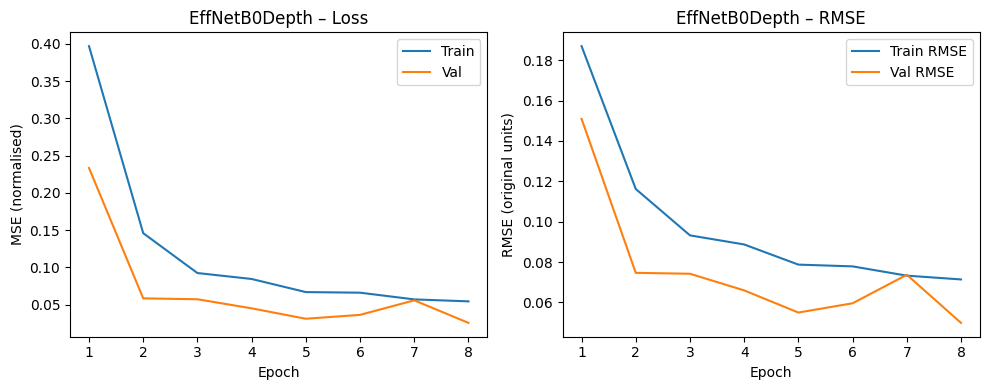

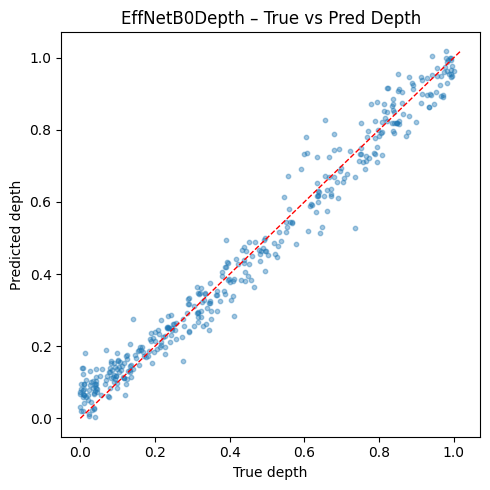

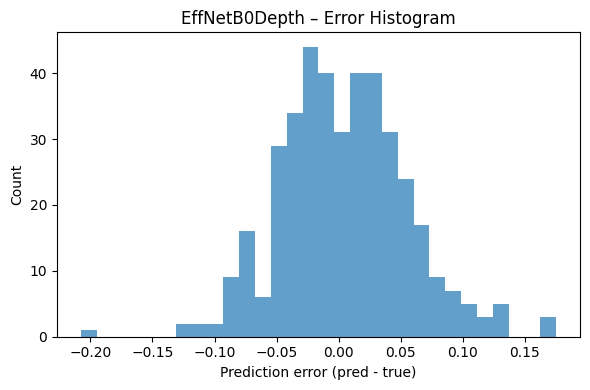

In [ ]:
# class for modified EffB0 depth regression model
class EffNetB0Depth(nn.Module):
    def __init__(self, pretrained=True): # constructor 
        super().__init__() # parent 
        self.backbone = models.efficientnet_b0( # load backbone with pretrained weights from torchvsison
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_features = self.backbone.classifier[1].in_features  #store input feature lenght
        
        self.backbone.classifier = nn.Sequential( # modify final classifier layer of EffB0
            nn.Linear(in_features, 256), # map input features to 256
            nn.ReLU(inplace=True), # ReLu activation
            nn.Dropout(p=0.3),# dropout rate set to 0.3 
            nn.Linear(256, 1)# final mapping from 256 to 1 for regression
        )
    # forward pass function
    def forward(self, x):
        out = self.backbone(x) #(B,1)
        return out.squeeze(1)# (B,) for easier metrics computing

# create instance of th emodel and load to device
model_depth_effb0 = EffNetB0Depth(pretrained=True).to(device)
criterion_depth = nn.MSELoss() # setting loss as MSE as before
optimizer_depth_effb0 = optim.Adam(model_depth_effb0.parameters(), lr=1e-4) # setting optimizr adam with same learning rate as previous models

num_epochs = 8 # number of epochs set to 8
best_val_rmse = float("inf") # bets validation rmse place holder
best_state_effb0 = None # best model weights placeholder

train_hist_effb0 = {"loss": [], "rmse": []} # trainign loss adn rmse history dictionary
val_hist_effb0   = {"loss": [], "rmse": []} # validation loss and rmse storing dictionary
#for epochs from 1-8
for epoch in range(1, num_epochs + 1):
    train_loss, train_rmse = train_one_epoch_depth( # train for one epoch using predefined fucntion
        model_depth_effb0, train_loader, optimizer_depth_effb0,
        criterion_depth, device, depth_mean_train, depth_std_train # input model to train, train loader, optimizer= adam, loss = mse
    )
    # evaluate model using predefined fucntion for current trained epch on validation data to get validation rmse and loss
    val_loss, val_rmse = evaluate_depth(
        model_depth_effb0, val_loader, # model, loss fucntion = mse, validation data loader
        criterion_depth, device, depth_mean_train, depth_std_train
    )
    
    train_hist_effb0["loss"].append(train_loss) # append training loss for current epoch
    train_hist_effb0["rmse"].append(train_rmse) # append training rmse for current epoch
    val_hist_effb0["loss"].append(val_loss) # append validation loss for current epoch
    val_hist_effb0["rmse"].append(val_rmse)# append validation rmse for current epoch
    # update best model placeholder if lower rmse obtained
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state_effb0 = model_depth_effb0.state_dict()
    # print obtaine dtraingin and validation loss and rmse
    print(f"[EffNetB0Depth] Epoch {epoch:02d}/{num_epochs} "
          f"| Train loss: {train_loss:.4f}, RMSE: {train_rmse:.4f} "
          f"| Val loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}")
# print model weights and validation accuracy for the best model (lowest validation rmse)
if best_state_effb0 is not None:
    model_depth_effb0.load_state_dict(best_state_effb0)
    print(f"\nLoaded best EffNetB0Depth with val RMSE = {best_val_rmse:.4f}")

# Testset evaluation using predefined helper function
test_loss, test_rmse = evaluate_depth( 
    model_depth_effb0, test_loader, # model to test, test data loader, loss fucntion
    criterion_depth, device, depth_mean_train, depth_std_train
)
print(f"EffNetB0Depth | Test loss (MSE norm): {test_loss:.4f}, Test RMSE: {test_rmse:.4f}") # print test loss and rmse

# Plot loass and rmse trainfin an validation curves from dictionaries with predefined helper fucntion
plot_loss_rmse_curves(train_hist_effb0, val_hist_effb0, title_prefix="EffNetB0Depth")
# get predicted and true values from test set evalueation using predefined helper fucntion
y_true_effb0, y_pred_effb0 = get_depth_predictions(
    model_depth_effb0, test_loader, device, depth_mean_train, depth_std_train
)
# plot true vs predicted scatter plot and error histogram for error analysis
plot_true_vs_pred_depth(y_true_effb0, y_pred_effb0, title="EffNetB0Depth – True vs Pred Depth")
plot_depth_error_histogram(y_true_effb0, y_pred_effb0, title="EffNetB0Depth – Error Histogram")


In [ ]:
# get predicted and true values
y_true_effb0, y_pred_effb0 = get_depth_predictions(
    model_depth_effb0, test_loader, device,
    depth_mean_train, depth_std_train
)
# compte r sqaured and print
test_r2_effb0 = r2_score_depth(y_true_effb0, y_pred_effb0)
print(f"EfficientNetB0Depth | Test R²: {test_r2_effb0:.4f}")

EfficientNetB0Depth | Test R²: 0.9733


### 4. Fusion (Eff+Res) Model Depth Implementation

In [ ]:
"""
Reference / conceptual inspiration for deep feature fusion:

K. Ahmad, K. Khan, and A. Al-Fuqaha,
“Intelligent Fusion of Deep Features for Improved Waste Classification,”
IEEE Access, vol. 8, pp. 96495–96504, 2020.

This work motivates the fusion of deep features extracted from multiple
CNN backbones, followed by joint classification using a shared fully
connected layer.
"""

Using device: cpu
Number of pose classes: 40
[FusionDepth] Epoch 01/8 | Train loss: 0.1922, RMSE: 0.1244 | Val loss: 0.0668, RMSE: 0.0805
[FusionDepth] Epoch 02/8 | Train loss: 0.0784, RMSE: 0.0842 | Val loss: 0.0380, RMSE: 0.0608
[FusionDepth] Epoch 03/8 | Train loss: 0.0564, RMSE: 0.0706 | Val loss: 0.0460, RMSE: 0.0669
[FusionDepth] Epoch 04/8 | Train loss: 0.0512, RMSE: 0.0669 | Val loss: 0.1043, RMSE: 0.1006
[FusionDepth] Epoch 05/8 | Train loss: 0.0542, RMSE: 0.0682 | Val loss: 0.0591, RMSE: 0.0759
[FusionDepth] Epoch 06/8 | Train loss: 0.0385, RMSE: 0.0599 | Val loss: 0.0150, RMSE: 0.0380
[FusionDepth] Epoch 07/8 | Train loss: 0.0305, RMSE: 0.0531 | Val loss: 0.0255, RMSE: 0.0497
[FusionDepth] Epoch 08/8 | Train loss: 0.0352, RMSE: 0.0570 | Val loss: 0.0144, RMSE: 0.0373

Loaded best FusionDepth with val RMSE = 0.0373
FusionDepth | Test loss (MSE norm): 0.0123, Test RMSE: 0.0345


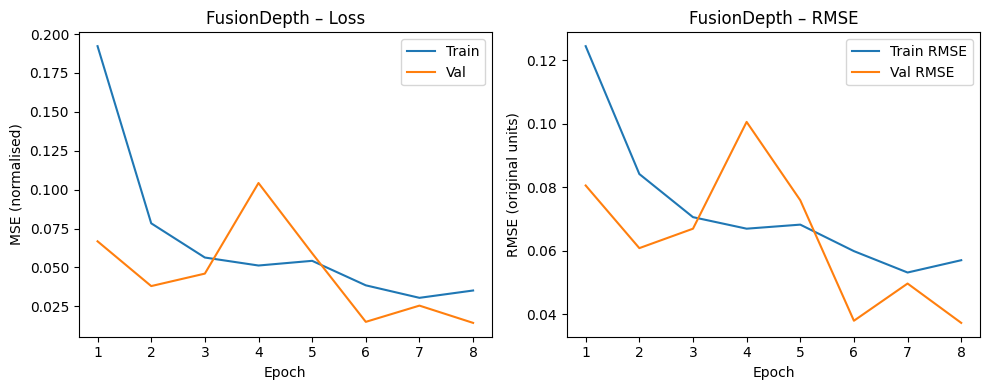

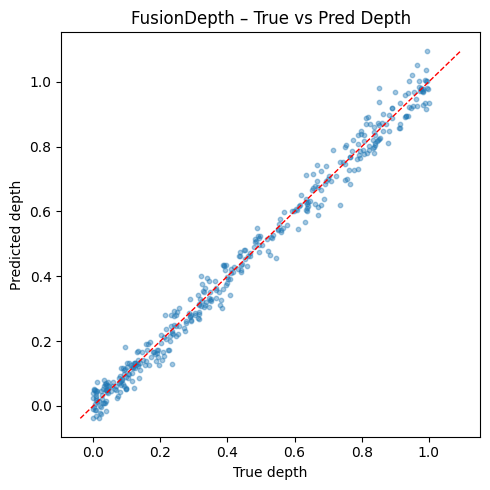

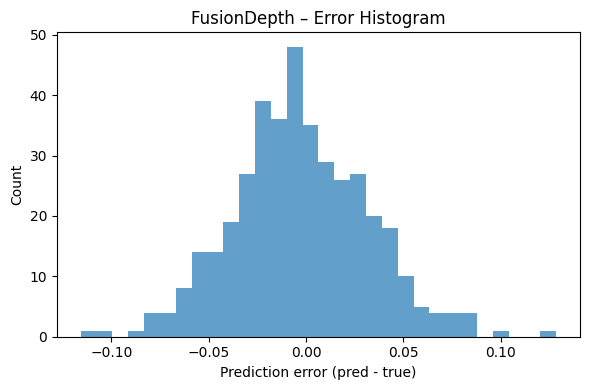

In [ ]:
# class for defining modified fusion model for depth regression
class FusionEffResNetDepth(nn.Module):
    def __init__(self, pretrained=True, freeze_backbones=False, dropout_p=0.3): # constructor for modified fusion model compatible for depth regression
        super().__init__() # initialize as parent 
       # 1) EfficientNet-B0 
        self.eff = models.efficientnet_b0( # load model backbone with pretrained weights  of efficientnet B0
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )
        eff_in_features = self.eff.classifier[1].in_features  # store input features of effcient net b0
        self.eff.classifier = nn.Identity() # modify final classifier layer as identity layer to keep as features for concatenation
        
        # load resnet-18 backbone with pretrained weights
        self.res = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        res_in_features = self.res.fc.in_features  #number of input features of resnet 18
        self.res.fc = nn.Identity() # modifying the final fully connected layer fo resnet into Identity to store features instead of logits
        
        fusion_dim = eff_in_features + res_in_features  # concatenating the features of resNet and Efficient net-b0
        
        # freexinign backbones if set to true to use the pretrained weights 
        if freeze_backbones:
            for p in self.eff.parameters():
                p.requires_grad = False
            for p in self.res.parameters():
                p.requires_grad = False
        
        # fused regression layer
        self.reg_head = nn.Sequential(
            nn.Linear(fusion_dim, 512), # map the concatenated feaure layer to 512
            nn.ReLU(inplace=True),# use ReLU activation fucntion
            nn.Dropout(p=dropout_p), # initialize dropout as 0.3
            nn.Linear(512, 1) # final layer maps 512->1 for predicted a final depth value
        )
    # forward pass function
    def forward(self, x):
        feat_eff = self.eff(x)   # (B, 1280) pass through eff
        feat_res = self.res(x)   # (B, 512) pass through resnet-18
        fused   = torch.cat([feat_eff, feat_res], dim=1)  # (B, 1792) use torch.cat to conacatenate the features to 1D
        out     = self.reg_head(fused)                    # (B,1) extract output from forward pass
        return out.squeeze(1)  # (B,) # for easier computation of metrics

# create instance of fusion model with dropu out rate set to 0.3 and move to device
model_depth_fusion = FusionEffResNetDepth(
    pretrained=True,
    freeze_backbones=False,
    dropout_p=0.3
).to(device)

criterion_depth = nn.MSELoss() # MSE as loss fucntion
optimizer_depth_fusion = optim.Adam(model_depth_fusion.parameters(), lr=1e-4) # adam optimizer with same learning rate as previous models

num_epochs = 8 # number of epochs set to 8 as before
best_val_rmse = float("inf") # place holder for best validation rmse
best_state_fusion = None # place holder of corresponding best weights 

train_hist_fusion = {"loss": [], "rmse": []} # dictionary to store traingin histoty over epochs
val_hist_fusion   = {"loss": [], "rmse": []} # dictionary to store validation history over ht eepochs

# for epochs from 1-8
for epoch in range(1, num_epochs + 1):
    train_loss, train_rmse = train_one_epoch_depth( # train for one epoch using predefined fucntion to get trainign liss and rmse for that epoch
        model_depth_fusion, train_loader, optimizer_depth_fusion, # input the model to be trained, loss fucntion= mse, optimizayion fucntion = adam, training data loader
        criterion_depth, device, depth_mean_train, depth_std_train
    )
    val_loss, val_rmse = evaluate_depth( # evaluated the model at the current epoch stage using teh validation fucntion to get validation rmse and lsos
        model_depth_fusion, val_loader, # input model, validation data loader, and loss fucntion 
        criterion_depth, device, depth_mean_train, depth_std_train
    )
    
    train_hist_fusion["loss"].append(train_loss) # append the training loss for the current epoch
    train_hist_fusion["rmse"].append(train_rmse) # append the training rmse for the current epoch
    val_hist_fusion["loss"].append(val_loss) # append the validation loss for the current epoch
    val_hist_fusion["rmse"].append(val_rmse) # append the validation rmse for the current epoch
    
    # update the model weights if validation accuracy of current epoch is ht elowest
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state_fusion = model_depth_fusion.state_dict()
    # printing current epoch traingin and validation loss and rmse for monitoring
    print(f"[FusionDepth] Epoch {epoch:02d}/{num_epochs} "
          f"| Train loss: {train_loss:.4f}, RMSE: {train_rmse:.4f} "
          f"| Val loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}")
# pringint best model validation accuracy as loaded for confirmation
if best_state_fusion is not None:
    model_depth_fusion.load_state_dict(best_state_fusion)
    print(f"\nLoaded best FusionDepth with val RMSE = {best_val_rmse:.4f}")

# Testse evaluation of final trained model using predefined fucntion
test_loss, test_rmse = evaluate_depth(
    model_depth_fusion, test_loader, # input model to be tested, test loader, loss fucntion=mse
    criterion_depth, device, depth_mean_train, depth_std_train
)
# printing tes loss and rmse of fully trained model
print(f"FusionDepth | Test loss (MSE norm): {test_loss:.4f}, Test RMSE: {test_rmse:.4f}")

# plotting loss and rmse validation and trainign crves from dictionaries
plot_loss_rmse_curves(train_hist_fusion, val_hist_fusion, title_prefix="FusionDepth")
# getting predictions and true vealues using predefined fucntion
y_true_fusion, y_pred_fusion = get_depth_predictions(
    model_depth_fusion, test_loader, device, depth_mean_train, depth_std_train # input model, test loader
)
#plot true vs. predicted scatter plot and plotting the error histogram for error analysis
plot_true_vs_pred_depth(y_true_fusion, y_pred_fusion, title="FusionDepth – True vs Pred Depth")
plot_depth_error_histogram(y_true_fusion, y_pred_fusion, title="FusionDepth – Error Histogram")

In [ ]:
#compute r squared if fused model
y_true_fus, y_pred_fus = get_depth_predictions(
    model_depth_fusion, test_loader, device,
    depth_mean_train, depth_std_train
)
test_r2_fus = r2_score_depth(y_true_fus, y_pred_fus)
print(f"ResNet18+EffB0 | Test R²: {test_r2_fus:.4f}")

ResNet18+EffB0 | Test R²: 0.9878


## Integration (Multi-Task Model for Depth and Pose Estimation) 


The best model for both tasks was used for integration.

In [ ]:
"""
Reference / inspiration for multi-task learning and integrated models:

Data Scientists Diary (Medium).
“A Guide to Multi-Task Learning in Machine Learning”.
https://medium.com/data-scientists-diary/a-guide-to-multi-task-learning-in-machine-learning-768d22b88715

Additional references:
- PyTorch documentation (multi-output models and loss functions):
  https://pytorch.org/docs/stable/nn.html
- PyTorch Tutorials (training loops and optimization):
  https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

This reference motivates the shared-representation learning strategy used
in the integrated multi-task model, where a common backbone is trained
jointly for pose classification and depth regression using task-specific heads.
"""

In [ ]:
# class for integrated model for depth regression and pose estimation using fusion model
class FusionEffResNetMultiTask(nn.Module):
    def __init__(self, num_classes, pretrained=True, freeze_backbones=False, dropout_p=0.3): # constructor that takes input as number of classes and dropout rate (default = 0.3)
        super().__init__()# set as parent
     # loadingin efficientnet weights from torch vision
        self.eff = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )
        eff_in_features = self.eff.classifier[1].in_features  # 1280 input features of effb0
        self.eff.classifier = nn.Identity() # setting final classifier layer as identity to output features instead of logits for concatenation
        
        # ResNet18 backbone loaded with pretrained weights from torch vision
        self.res = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        res_in_features = self.res.fc.in_features  # 512 input features stored of res-18
        self.res.fc = nn.Identity() # final fully connected layer set as identity to output features to the next layer instead of logits for concatenation
        
        self.fusion_dim = eff_in_features + res_in_features  # 1792 combining the features of resnet18 and effb0
        
        # freeze backbones if set to true
        if freeze_backbones:
            for p in self.eff.parameters():
                p.requires_grad = False
            for p in self.res.parameters():
                p.requires_grad = False
        
        # shared final layer with two heads one classifier and one regression 
        # pose classification layer
        self.pose_head = nn.Sequential(
            nn.Linear(self.fusion_dim, 512),  # map fused features to 512 (captures most features without overfitting)
            nn.ReLU(inplace=True),# using reLU activation
            nn.Dropout(p=dropout_p), # dropout rate set to 0.3
            nn.Linear(512, num_classes)# maps 512 to 40 for classification
        )
        # depth regression layer
        self.depth_head = nn.Sequential(
            nn.Linear(self.fusion_dim, 512), # map fused features to 512
            nn.ReLU(inplace=True), # ReLU activation to prevent vanishing gradient problem
            nn.Dropout(p=dropout_p),# dropout rate set to 0.3
            nn.Linear(512, 1)# map 512 to 1 for regression prediction one final depth value
        )
    # forward pass fucntion
    def forward(self, x):
        feat_eff = self.eff(x) # (B, 1280) pass through effb0
        feat_res = self.res(x) # (B, 512) pass through resnet 
        fused   = torch.cat([feat_eff, feat_res], dim=1)  # (B, 1792) concatenate fused layers
        logits  = self.pose_head(fused)# (B, num_classes) logits for each class
        depth_norm = self.depth_head(fused).squeeze(1)  # (B,) predicted depth value
        return logits, depth_norm # return logits for each class and final depth normalized prediction


#### Helper Functions for Training and Evaluation

In [ ]:
# fucntion: train one epoch of integrated model
# inputs= model, training data loader, optimizer, cross entropy loss fucntion, mse loss fucntion, device, depth mean dna satndard deviation for denormalization, 
# and lambda depth (weight of depth loss fucntion in combined loss fucntion)
# output = training loss (overall), rmse (depth) and accuracy (pose)
def train_one_epoch_multitask(
    model, dataloader, optimizer,
    ce_criterion, mse_criterion,
    device,
    depth_mean_train, depth_std_train,
    lambda_depth=1.0
):
    model.train()# setting model to train mode (dropout BN activated)
    running_loss = 0.0 # accumulator for traingin loss
    running_acc  = 0.0 # ccumulator for traingin accurcay
    running_rmse = 0.0 # accumulator for trainging rmse
    total_samples = 0 # accumulator for total samples
    total_batches = 0 # accumulator for batch counting
    
    # iterate through batches
    for images, pose_labels, depths_norm in dataloader:
        images      = images.to(device) # load iamges to devide
        pose_labels = pose_labels.to(device).long() # move pose labels to devide and convert to long
        depths_norm = depths_norm.to(device).float() # move normalized depth values to device and set as float
        
        optimizer.zero_grad() # clear previous gradients
        
        logits, pred_depth_norm = model(images) # forward pass with the current batch
        
        loss_pose  = ce_criterion(logits, pose_labels) # compute classification loss
        loss_depth = mse_criterion(pred_depth_norm, depths_norm) # cocmpute regression loss
        loss = loss_pose + lambda_depth * loss_depth # combine losses
        
        loss.backward() # comput gradients of loss backpropogation
        optimizer.step() # update model parameters using optimizer 
        
        _, preds = torch.max(logits, dim=1) # take class index with the highest logits score (highest proability)
        correct = (preds == pose_labels).sum().item()# count how many predictions match trie labels in current batch
        batch_size = images.size(0) #get total number of samples in the current batch
        
        # compute rmse with orginal depth values using predefined fucntion
        batch_rmse = rmse_from_normalised(
            pred_depth_norm.detach().cpu(), #detech predicted depth from cpu for NumPy conversion
            depths_norm.detach().cpu(), # detach true depth for NumPy conversion
            depth_mean_train,# trainging depth mean used for standardization
            depth_std_train #traingin standard deviation of depth values
        )   
        
        running_loss += loss.item()#increment total training loss value for averaging later
        running_acc  += correct #increment number of correct classifications for computing accuracy
        running_rmse += batch_rmse #increment rmse values per batch 
        total_samples += batch_size #accumulate total number of samples till current batch
        total_batches += 1 #counter for hoe many batches have been processed
    
    epoch_loss = running_loss / total_batches #compute mean loss per batch
    epoch_acc  = running_acc  / total_samples #compute accuracy over epochs
    epoch_rmse = running_rmse / total_batches #compute rmse per batch over epochs
    
    return epoch_loss, epoch_acc, epoch_rmse #return eaach epoch level rmse loss and accurcay



#function: evaluation fucntion using validation data 
# inputs: model, validation dataloader, pose_loss fucntion, regression_loss fucntion, depth mean and standard deviation, lambda depth (default =1)
@torch.no_grad() #disbale gradient computation during evaluation
def evaluate_multitask( 
    model, dataloader,  
    ce_criterion, mse_criterion, 
    device,  
    depth_mean_train, depth_std_train,
    lambda_depth=1.0  #weighting relative to depth loss for loss fucntion
):
    model.eval() # set model to evaluation model (turns off dropout)
    running_loss = 0.0 # accumulator for traingin loss
    running_acc  = 0.0 # ccumulator for traingin accurcay
    running_rmse = 0.0 # accumulator for trainging rmse
    total_samples = 0 # accumulator for total samples
    total_batches = 0 # accumulator for batch counting

     # iterate through batches
    for images, pose_labels, depths_norm in dataloader:
        images      = images.to(device) # load iamges to devide
        pose_labels = pose_labels.to(device).long() # move pose labels to devide and convert to long
        depths_norm = depths_norm.to(device).float() # move normalized depth values to device and set as float
        
        logits, pred_depth_norm = model(images) # forward pass with the current batch
        
        loss_pose  = ce_criterion(logits, pose_labels) # compute classification loss
        loss_depth = mse_criterion(pred_depth_norm, depths_norm) # cocmpute regression loss
        loss = loss_pose + lambda_depth * loss_depth # combine losses
        
        _, preds = torch.max(logits, dim=1) # take class index with the highest logits score (highest proability)
        correct = (preds == pose_labels).sum().item()# count how many predictions match trie labels in current batch
        batch_size = images.size(0) #get total number of samples in the current batch
        
        # compute rmse with orginal depth values using predefined fucntion
        batch_rmse = rmse_from_normalised(
            pred_depth_norm.detach().cpu(), #detech predicted depth from cpu for NumPy conversion
            depths_norm.detach().cpu(), # detach true depth for NumPy conversion
            depth_mean_train,# trainging depth mean used for standardization
            depth_std_train #traingin standard deviation of depth values
        )   
        
        running_loss += loss.item()#increment total training loss value for averaging later
        running_acc  += correct #increment number of correct classifications for computing accuracy
        running_rmse += batch_rmse #increment rmse values per batch 
        total_samples += batch_size #accumulate total number of samples till current batch
        total_batches += 1 #counter for hoe many batches have been processed
    
    epoch_loss = running_loss / total_batches #compute mean loss per batch
    epoch_acc  = running_acc  / total_samples #compute accuracy over epochs
    epoch_rmse = running_rmse / total_batches #compute rmse per batch over epochs
    
    return epoch_loss, epoch_acc, epoch_rmse #return eaach epoch level rmse loss and accurcay for validation

from torch.nn import functional as F # import functional API as F

#function: gets predicted and true values 
# inputs: model, testing data, device 
# returns all predicted and corresponding true values nad prbabilities
@torch.no_grad()# disables computation of gradient during evaluation
def get_preds_labels_probs(model, dataloader, device, multitask=False): 
    model.eval() # set model to evaluation model 
    all_preds = [] # list to collect predicted class indices
    all_labels = [] #list to collect true labels of corresponding predictions
    all_probs = []#list to collect probabilities for each batch
    
    for images, pose_labels, depths_norm in dataloader: #iterate over bathces in hte test data
        images = images.to(device)#move images to device
        pose_labels = pose_labels.to(device).long() #move labels to device and. cast to long

        if multitask: # check whether model is set to multitask for depth + pose estimation
            logits, _ = model(images) #get classification logits andignore depth prediction value for now in forward pass of th emodel
        else:
            logits = model(images)# single task classifier retunrs pose logits only
        
        probs = F.softmax(logits, dim=1) # convert logits to prababilities using soft max accross the 40 classes
        preds = probs.argmax(dim=1) # predicted class index set as the max probabaility 
        
        all_preds.append(preds.cpu())# append predicted indices
        all_labels.append(pose_labels.cpu())#append tru values
        all_probs.append(probs.cpu())#append predicted probabilities
    
    all_preds  = torch.cat(all_preds).numpy() # concatenate all predicted values form all the batches
    all_labels = torch.cat(all_labels).numpy() #concatenate all true values over all the batches and convert to NumPy array
    all_probs  = torch.cat(all_probs).numpy()  # concatenate all probabilities and convert to NumPy array
    
    return all_preds, all_labels, all_probs # return predictions, labels, and probabilities


In [ ]:
# create instance from predefined class for multitask model
multi_model = FusionEffResNetMultiTask(
    num_classes=num_classes,
    pretrained=True,
    freeze_backbones=False,
    dropout_p=best_drop  # fdropout rate set to best rate for pose classificatio from parameter hyper tuning
).to(device)

ce_criterion  = nn.CrossEntropyLoss() # pose classification loss fucntion set to cross entropy
mse_criterion = nn.MSELoss()# regression loss fucntion set to mse

# adam optimizer with learning rate set as the best hyper tuned value for pose clssification
optimizer_multi = optim.Adam(
    multi_model.parameters(),
    lr=best_lr, 
    weight_decay=0.0 
)

num_epochs = 15 # number of epochs set to 15 instead of 8 as pose classification converges around 15 epochs
lambda_depth = 1.0 # lambda or weight of depth regssion loss set to 50 50 

best_val_score = -1.0 # best validation accuracy set to -1 as a place holder
best_state_multi = None # best model weights set to None as lace holder

train_hist_multi = {"loss": [], "acc": [], "rmse": []} # dictionary for storing training loss rmse and accurcay
val_hist_multi   = {"loss": [], "acc": [], "rmse": []} # dictionary for storing validation loss accurcay and rmse

# for epochs from 1-15
for epoch in range(1, num_epochs + 1):
    # train for current epoch using predefined fucntion 
    train_loss, train_acc, train_rmse = train_one_epoch_multitask( # get trainign loass accurcay and rmse for current epoch
        multi_model, train_loader, optimizer_multi, # input model, trainng data, optimizer, cross entropy, mse loss
        ce_criterion, mse_criterion,
        device,
        depth_mean_train, depth_std_train,
        lambda_depth=lambda_depth
    )
    # evaluate model on validation data using predefined helper fucntion
    val_loss, val_acc, val_rmse = evaluate_multitask(# get validation loss adn accurcay rmse
        multi_model, val_loader,  # model, validation data loader, loss mse, cross entropy loss
        ce_criterion, mse_criterion,
        device,
        depth_mean_train, depth_std_train,
        lambda_depth=lambda_depth
    )
    
    train_hist_multi["loss"].append(train_loss) # append overall training loss in dictionary for current epoch
    train_hist_multi["acc"].append(train_acc)# append overall training rmse in dictionary for current epoch
    train_hist_multi["rmse"].append(train_rmse)# append overall training accuracy in dictionary for current epoch
    val_hist_multi["loss"].append(val_loss)# append overall validation loss in dictionary for current epoch
    val_hist_multi["acc"].append(val_acc)# append overall validation accuracy in dictionary for current epoch
    val_hist_multi["rmse"].append(val_rmse)# append overall validation rmse in dictionary for current epoch
    
    # select model with best validation accuracy
    if val_acc > best_val_score:
        best_val_score = val_acc
        best_state_multi = multi_model.state_dict()
    # print training loss rmse and accuracy for each epoch for monitoing
    print(
        f"[MultiTask] Epoch {epoch:02d}/{num_epochs} "
        f"| Train loss: {train_loss:.4f}, acc: {train_acc:.4f}, rmse: {train_rmse:.4f} "
        f"| Val loss: {val_loss:.4f}, acc: {val_acc:.4f}, rmse: {val_rmse:.4f}"
    )
# print best model loaded
if best_state_multi is not None:
    multi_model.load_state_dict(best_state_multi)
    print(f"\nLoaded best multi-task model with val acc = {best_val_score:.4f}")


[MultiTask] Epoch 01/15 | Train loss: 3.7404, acc: 0.1258, rmse: 0.1405 | Val loss: 3.3481, acc: 0.3625, rmse: 0.1439
[MultiTask] Epoch 02/15 | Train loss: 2.7009, acc: 0.4433, rmse: 0.0915 | Val loss: 1.8599, acc: 0.6000, rmse: 0.0753
[MultiTask] Epoch 03/15 | Train loss: 1.5661, acc: 0.6950, rmse: 0.0913 | Val loss: 0.9235, acc: 0.8275, rmse: 0.0721
[MultiTask] Epoch 04/15 | Train loss: 0.8544, acc: 0.8408, rmse: 0.0938 | Val loss: 0.5161, acc: 0.8825, rmse: 0.0724
[MultiTask] Epoch 05/15 | Train loss: 0.4848, acc: 0.9200, rmse: 0.0820 | Val loss: 0.2840, acc: 0.9575, rmse: 0.0626
[MultiTask] Epoch 06/15 | Train loss: 0.3257, acc: 0.9583, rmse: 0.0860 | Val loss: 0.1726, acc: 0.9700, rmse: 0.0510
[MultiTask] Epoch 07/15 | Train loss: 0.2378, acc: 0.9725, rmse: 0.0855 | Val loss: 0.2282, acc: 0.9925, rmse: 0.1222
[MultiTask] Epoch 08/15 | Train loss: 0.1827, acc: 0.9867, rmse: 0.0832 | Val loss: 0.0811, acc: 0.9950, rmse: 0.0513
[MultiTask] Epoch 09/15 | Train loss: 0.1439, acc: 0.994

TUNED Fusion EffNetB0 + ResNet18 – Test metrics
Accuracy: 0.9875
Precision (macro): 0.9897
Recall (macro):    0.9875
F1-score (macro):  0.9873


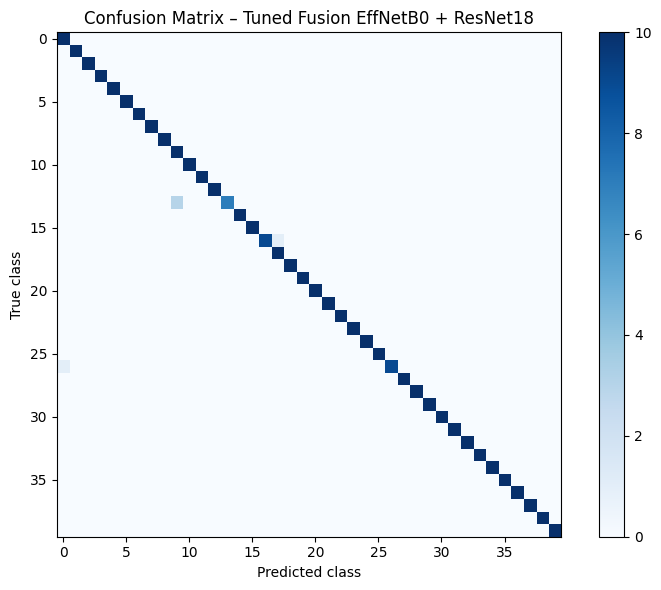

In [ ]:
# get pose predictions and true values using predefined fucntion helper
y_pred_pose, y_true_pose, _ = get_preds_labels_probs(
    multi_model, test_loader, device, multitask=True 
)
#compute accuracy, precision, recall and F1 score
acc = accuracy_score(y_true_pose, y_pred_pose)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true_pose, y_pred_pose,
    average="macro",
    zero_division=0
)
# print evaluation metrics
print("TUNED Fusion EffNetB0 + ResNet18 – Test metrics")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro):    {rec:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

# plot confusion matrix
cm_fusion = confusion_matrix(y_true_pose, y_pred_pose)
plt.figure(figsize=(8, 6))
plt.imshow(cm_fusion, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix – Tuned Fusion EffNetB0 + ResNet18")
plt.colorbar()
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

In [ ]:
# depth predictions
multi_model.eval() # set model to evaluation
all_depth_pred = [] # list for storing all depth values
all_depth_true = [] # list for storing all true prediction values

with torch.no_grad():
    for images, pose_labels, depths_norm in test_loader: # iterate throuhg batches in the test loader
        images = images.to(device) # move images to device
        depths_norm = depths_norm.to(device).float() # move depth values to device and convert to float
        logits, pred_depth_norm = multi_model(images) # forward pass get logts and predicted depth normalized
        
        all_depth_pred.append(pred_depth_norm.cpu()) # append predicted depth for batch
        all_depth_true.append(depths_norm.cpu()) # appened true depth for batch

all_depth_pred = torch.cat(all_depth_pred) # concatenate all pred depth values
all_depth_true = torch.cat(all_depth_true) # concatenate all true depth values

# denormalize and compute r squares
y_pred_depth = all_depth_pred.numpy() * depth_std_train + depth_mean_train
y_true_depth = all_depth_true.numpy() * depth_std_train + depth_mean_train

rmse_test = rmse_from_normalised(all_depth_pred, all_depth_true, depth_mean_train, depth_std_train)
r2_test   = r2_score_depth(y_true_depth, y_pred_depth)

print(f"Multi-task Fusion | Test depth RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}")

Multi-task Fusion | Test depth RMSE: 0.0516, R²: 0.9735


## Saving all the trained model weights into pth files

In [ ]:
"""
Reference for saving and loading PyTorch models:

PyTorch Documentation.
“Save and Load the Model”.
https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html

This reference guides the use of state_dict-based model checkpointing
and restoration during training and evaluation.
"""

In [ ]:
import torch
from pathlib import Path

save_dir = Path("saved_models") # assigning folder or savinng all the model weights
save_dir.mkdir(parents=True, exist_ok=True) # creates a new directory saved_models if it doesnt exist

models_to_save = {
    # initializing file names for pose models
    "pose_resnet18.pth":          model_resnet18,
    "pose_resnet50.pth":          model_resnet50,
    "pose_effnetb0.pth":          model_effb0,
    "pose_fusion_effres.pth":     fusion_model_final,    

    # initializing depth model file names
    "depth_resnet18.pth":         model_depth_resnet18,
    "depth_effnetb0.pth":         model_depth_effb0,
    "depth_fusion_effres.pth":    model_depth_fusion,

    #final integrated model(depth+pose)
    "integrated_depth_pose.pth":  multi_model,

}
# iterating through the file names
for filename, model in models_to_save.items():
    if model is None:
        continue  
    path = save_dir / filename # setting path to saved_models directory
    torch.save(model.state_dict(), path) # save the model weights in the saved_models directory
    print(f"Saved: {path}")

Saved: saved_models\pose_resnet18.pth
Saved: saved_models\pose_resnet50.pth
Saved: saved_models\pose_effnetb0.pth
Saved: saved_models\pose_fusion_effres.pth
Saved: saved_models\depth_resnet18.pth
Saved: saved_models\depth_effnetb0.pth
Saved: saved_models\depth_fusion_effres.pth
Saved: saved_models\integrated_depth_pose.pth
